# 2D Implmentation of the Helmoltz solver

2D Helmholtz Equation: Finite Difference Derivation and Spectral Decomposition

The 2D Helmholtz equation is:

$$
\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} + k^2 u = f(x, y)
$$

Discretization
* Domain: Split into an $ N \times M $ grid with spacing $ h = \frac{1}{N+1} $ in $ x $ and $ y $.
* Let $ u_{i,j} \approx u(x_i, y_j) $ and $ f_{i,j} = f(x_i, y_j) $, where $ x_i = ih $ and $ y_j = jh $.


Central Difference Approximation
The second derivatives are approximated as:

$$
\frac{\partial^2 u}{\partial x^2} \approx \frac{u_{i-1,j} - 2u_{i,j} + u_{i+1,j}}{h^2}, \quad \frac{\partial^2 u}{\partial y^2} \approx \frac{u_{i,j-1} - 2u_{i,j} + u_{i,j+1}}{h^2}
$$

Substituting into the Helmholtz Equation
$$
\frac{u_{i-1,j} + u_{i+1,j} + u_{i,j-1} + u_{i,j+1} - 4u_{i,j}}{h^2} + k^2 u_{i,j} = f_{i,j}
$$

Rearranging gives the linear equation for interior points:

$$
\frac{1}{h^2}u_{i-1,j} + \frac{1}{h^2}u_{i+1,j} + \frac{1}{h^2}u_{i,j-1} + \frac{1}{h^2}u_{i,j+1} + \left(\frac{-4}{h^2} + k^2\right)u_{i,j} = f_{i,j}
$$

Spectral Decomposition in the $ y $-Direction
To preserve the tridiagonal structure, decompose the problem using the Discrete Sine Transform (DST)} for Dirichlet BCs (or DCT for Neumann BCs):

Forward DST on $ f(x, y) $
* For each column $ x_i $, compute the spectral coefficients:
$$
\tilde{f}_{i,m} = \text{DST}\left[f_{i,j}\right] = \sum_{j=1}^{N_y-1} f_{i,j} \sin\left(\frac{m \pi j}{N_y}\right)
$$
This diagonalizes the $ y $-Laplacian into eigenvalues $ \lambda_m^{(y)} = -\frac{4}{h^2} \sin^2\left(\frac{m \pi h}{2L_y}\right) $.

Modified 1D Helmholtz Equations in $ x $:

For each mode $ m $, solve:
$$
\frac{d^2 \tilde{u}_m}{dx^2} + \left(k^2 - \lambda_m^{(y)}\right)\tilde{u}_m = \tilde{f}_m(x)
$$
*This is a tridiagonal system} identical to the 1D case, with effective wavenumber $ k_{\text{eff}}^2 = k^2 - \lambda_m^{(y)} $.

Matrix Form for Each Mode}

*For each $ m $, the tridiagonal matrix $ A_m $ has:

* Diagonal entries: $ \frac{-2}{h^2} + k_{\text{eff}}^2 $
* Off-diagonal entries: $ \frac{1}{h^2} $
* Solve $ A_m \tilde{u}_m = \tilde{f}_m $ using your 1D solver.

Inverse DST to Reconstruct $ u(x, y) $}

*For each column $ x_i $, compute:
$$
u_{i,j} = \text{Inverse DST}\left[\tilde{u}_{i,m}\right] = \frac{2}{N_y+1} \sum_{m=1}^{N_y-1} \tilde{u}_{i,m} \sin\left(\frac{m \pi j}{N_y}\right)
$$

Matrix Structure Summary

* Original 2D System: Block tridiagonal (not directly solvable with a 1D tridiagonal solver).
* After Spectral Decomposition}: Independent 1D tridiagonal systems for each mode $ m $.
* Key Advantage: Retains the efficiency of your 1D code by reducing the 2D problem to $ M $ 1D solves.




### Import the necessary modules

In [3]:
# make use of QLS jupyter env
import numpy as np
import scipy as sc
from linear_solvers import NumPyLinearSolver, HHL
from linear_solvers.matrices.tridiagonal_toeplitz import TridiagonalToeplitz
from linear_solvers.matrices.numpy_matrix import NumPyMatrix
from qiskit.utils import QuantumInstance
from numerical_solvers.thomas_algorithm import numerical_solvers
from qiskit.quantum_info import Statevector
from qiskit import Aer, transpile, execute
from scipy.sparse import diags
from scipy.fft import dst, idst
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

warnings.simplefilter('ignore')

### Define the Utility functions which we will need:

In [4]:
from math import log2
from re import A
import stat
from qiskit.utils import QuantumInstance

def normalize(arr, t_min, t_max):
    """
    Normalize an array to a specified range [t_min, t_max].
    
    For data that spans both negative and positive values, this function
    uses a symmetric normalization (dividing by the maximum absolute value)
    to preserve the zero-crossing and the relative oscillatory behavior.
    
    For data that does not span both signs, it uses standard min-max normalization.
    """
    arr = np.array(arr)
    # Check if data spans both negative and positive values
    # Use symmetric normalization:
    max_abs = np.max(np.abs(arr))
    # Avoid division by zero
    if max_abs < 1e-12:
        norm_arr = arr.copy()
    else:
        norm_arr = arr / max_abs
    # If the target range is symmetric about zero (e.g., [-1, 1]),
    # then simply scale by the maximum absolute value.
    # Otherwise, map [-1, 1] to [t_min, t_max]:
    if t_min == -1 and t_max == 1:
        return norm_arr
    else:
        # Mapping from [-1,1] to [t_min, t_max]:
        return ((norm_arr + 1) / 2) * (t_max - t_min) + t_min
        
def qasm(solution, N, vector, backend, Nshots, backend_options, visual=False):
    """
    Extracts and normalizes the solution vector from measurement results of a quantum circuit.
    The circuit is executed using the provided backend and backend_options.
    
    Assumes that the measured bitstrings include the solution register as the last log2(len(vector)) bits.
    """

    # Record the start time
    start_time = time.time()
    
    vector_length = len(vector)
    sol_length = int(np.log2(vector_length))  # Number of qubits in solution register
    start = N - sol_length  # Starting index of the solution register
    
    # Get a copy of the circuit and add measurements
    qc = solution.state.copy()
    qc.measure_all()
    
    # Execute the circuit using the provided backend and backend options
    backend.set_options(**backend_options)
    job = execute(qc, backend, shots=Nshots)
    result = job.result()
    counts = result.get_counts(qc)
    total_shots = sum(counts.values())
    
    if visual:
        hist = counts
        # Create a histogram from the counts
        bitstrings = list(hist.keys())
        frequencies = list(hist.values())
    
        plt.figure(figsize=(10, 6))
        plt.xticks(rotation=45, ha='right')
        plt.bar(bitstrings, frequencies)
        plt.xlabel('Bitstrings')
        plt.ylabel('Counts')
        plt.grid(axis='y', alpha=0.5)
        plt.title('Histogram of QASM Results')
        plt.show()

    sol_counts = np.zeros(vector_length)  # Initialize the solution counts array

    # Process counts: extract only those bitstrings where the first bit is '1' and the clock bits (from index 1 to start-1) are all '0'
    for bitstring, count in counts.items():
        clock_bits = bitstring[1:start]
        if bitstring[0] == '1' and all(b == '0' for b in clock_bits):
            # Extract the solution register bits (from position 'start' onward)
            sol_bitstring = bitstring[start:]
            index = int(sol_bitstring, 2)
            sol_counts[index] += count

    # Compute probabilities, then amplitudes (square roots of probabilities)
    sol_probs = sol_counts / total_shots
    sol_amplitudes = np.sqrt(np.abs(sol_probs))
    
    # Scale the amplitudes by the euclidean norm provided by the solution object
    sol_norm = np.linalg.norm(sol_amplitudes)
    if sol_norm == 0:
        normalized_amplitudes = sol_amplitudes
    else:
        normalized_amplitudes = sol_amplitudes / sol_norm
        
    end_time = time.time()
    print(f"qasm execution time: {end_time - start_time}")
    
    return normalized_amplitudes

def statevector(solution, N, vector, Nshots):
    """Extracts and normalizes simulated state vector from LinearSolverResult."""
    # Record the start time
    start_time_total = time.time()
    start = int(2**(N-1))
    fin = int(2**(N-1) + len(vector))
    
    qc = solution.state.copy()
    qc.remove_final_measurements()

    backend = Aer.get_backend('statevector_simulator')
    job = execute(qc, backend, shots=Nshots)
    result = job.result()
    
    # Extract the state vector
    sv = result.get_statevector(qc)
    
    # Extraction
    solution_vector = sv.data[start:fin]
    solution_vector = np.real(solution_vector)
    
    #print("Statevector from Aer execution:", solution_vector)
    # Record the end time
    end_time = time.time()
    #print(f"State Vector execution time: {end_time - start_time_total}")
    
    return solution_vector

def construct_TT_matrix(main_diag, off_diag, size):
    '''
    Construct a tridiagonal Toeplitz matrix using the main diagonal and off-diagonal elements.
    '''
    matrix = diags([off_diag, main_diag, off_diag], offsets=[-1, 0, 1], shape=(size, size)).toarray()
    
    print(f'Matrix Condition number: {np.linalg.cond(matrix)}')
    return matrix

def construct_preconditioner(matrix, vector,h,k, alpha):
    """
    Return the numpy preconditioned matrix and vector for the given matrix and vector.
    """
    main_diag = matrix[0, 0]
    off_diag = matrix[0, 1]
    size = matrix.shape[0]

    # Build the complex-shifted Laplacian preconditioner
    a_shifted = -4 / h**2 + k**2 * (1 - 1j * alpha)
    b_shifted = 1 / h**2
    a_real = np.real(a_shifted)
    a_imag = np.imag(a_shifted)
    b_real = np.real(b_shifted)
    P_real = diags([b_real, a_real, b_real], [-1, 0, 1], shape=(size, size)).toarray()
    P_imag = diags([0, a_imag, 0], [-1, 0, 1], shape=(size, size)).toarray()
    P_complex = P_real + 1j * P_imag
    # Ensure the preconditioner matrix is positive definite
   # 7) Classical preconditioning
    P_inv = np.linalg.inv(P_complex)
    prec_matrix_complex = P_inv @ matrix
    prec_vector_complex = P_inv @ vector
    prec_matrix = np.real(prec_matrix_complex)
    prec_vector = np.real(prec_vector_complex)

    # 8) Approximate preconditioned matrix as TridiagonalToeplitz
    a_prec = np.mean(np.diag(prec_matrix))
    b_prec = np.mean(np.diag(prec_matrix, 1))

    matrix_prec = construct_TT_matrix(a_prec, b_prec, size)
    print('Preconditioner Condition number: ', np.linalg.cond(matrix_prec))
    return matrix_prec, prec_vector

def solve_1DHHL(matrix, vector, qubits, epsilon=0.001):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 10000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector)
 
    return hhl_solution_obj

def solve_1DHHL_Numpy(matrix, vector, qubits, epsilon=0.001):
    '''
    Solves the 1D HHL
    '''
    a = matrix[0, 0]
    b = matrix[0, 1]
    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 1000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    mat = NumPyMatrix(matrix)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(mat, vector)
 
    return hhl_solution_obj

def solve_1DHHL_prec(matrix, vector, qubits, alpha ,h,k,epsilon=0.001):
    '''
    Solves the 1D HHL using preconditioning
    '''
    matrix_prec, vector_prec = construct_preconditioner(matrix, vector, alpha, h, k)
    a = matrix_prec[0, 0]
    b = matrix_prec[0, 1]

    # Set up quantum instance
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }
    num_shots = 1000
    quantum_instance = QuantumInstance(backend, shots=num_shots, backend_options=backend_options)

    tridi_mat = TridiagonalToeplitz(qubits, a, b)
    hhl_solver = HHL(epsilon=epsilon, quantum_instance=quantum_instance)
    hhl_solution_obj = hhl_solver.solve(tridi_mat, vector_prec)
 
    return hhl_solution_obj

def solve_1DThomas(matrix, vector):
    '''
    Solves the 1D Thomas algorithm
    '''
    
    # Compare to thomas
    matrix1 = matrix.copy()
    vector1 = vector.copy()
    thomas = numerical_solvers()
    num_solution = thomas.solve_tridiagonal_thomas(matrix1, vector1)
    #num_solution = np.concatenate(([0], num_solution, [0]))
    #num_solution = normalize(num_solution, -1.0, 1.0)
    return num_solution

def generate_forcing_function(Nx, Ny, Lx, Ly, forcing_type='uniform', **kwargs):
    """
    Generates a forcing function (RHS) for the 2D Helmholtz equation.
    
    Parameters:
        Nx, Ny : int
            Number of interior grid points in the x and y directions.
        Lx, Ly : float
            Domain lengths in x and y.
        forcing_type : str
            Type of forcing function to generate:
            - 'uniform': Constant value across domain
            - 'point_source': Point source at specified location
            - 'gaussian': Gaussian source
            - 'sinusoidal': Sinusoidal pattern
            - 'manufactured': Manufactured solution (for verification)
            - 'custom': Custom function provided as lambda
        **kwargs : dict
            Additional parameters for specific forcing types:
            - 'uniform': value (default=1.0)
            - 'point_source': x0, y0 (position), amplitude (default=1.0)
            - 'gaussian': x0, y0 (center), sigma (width), amplitude (default=1.0)
            - 'sinusoidal': kx, ky (wave numbers), amplitude (default=1.0)
            - 'manufactured': k (wave number from Helmholtz operator)
            - 'custom': func (lambda function taking x, y arrays)
    
    Returns:
        f : numpy.ndarray
            The forcing function as a flattened array of shape (Nx*Ny,).
        f_grid : numpy.ndarray
            The forcing function as a 2D grid of shape (Ny, Nx).
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
    """
    # Compute grid spacings and coordinates
    hx = Lx / (Nx + 1)
    hy = Ly / (Ny + 1)
    
    # Create interior grid points
    x = np.linspace(hx, Lx - hx, Nx)
    y = np.linspace(hy, Ly - hy, Ny)
    x_grid, y_grid = np.meshgrid(x, y)
    
    # Initialize forcing function grid
    f_grid = np.zeros((Ny, Nx))
    
    # Generate forcing function based on type
    if forcing_type == 'uniform':
        value = kwargs.get('value', 1.0)
        f_grid = np.ones((Ny, Nx)) * value
        
    elif forcing_type == 'point_source':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        amplitude = kwargs.get('amplitude', 1.0)
        
        # Find closest grid point
        idx_x = np.argmin(np.abs(x - x0))
        idx_y = np.argmin(np.abs(y - y0))
        f_grid[idx_y, idx_x] = amplitude
        
    elif forcing_type == 'gaussian':
        x0 = kwargs.get('x0', Lx/2)
        y0 = kwargs.get('y0', Ly/2)
        sigma = kwargs.get('sigma', min(Lx, Ly)/8)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.exp(-((x_grid - x0)**2 + (y_grid - y0)**2) / (2 * sigma**2))
        
    elif forcing_type == 'sinusoidal':
        kx = kwargs.get('kx', np.pi/Lx)
        ky = kwargs.get('ky', np.pi/Ly)
        amplitude = kwargs.get('amplitude', 1.0)
        
        f_grid = amplitude * np.sin(kx * x_grid) * np.sin(ky * y_grid)
        
    elif forcing_type == 'manufactured':
        # For method of manufactured solutions, we choose a known solution u
        # and compute f = -∇²u - k²u
        k = kwargs.get('k', 1.0)
        
        # Define a known analytic solution that satisfies boundary conditions
        u_exact = np.sin(np.pi * x_grid / Lx) * np.sin(np.pi * y_grid / Ly)
        
        # Compute second derivatives for the Laplacian
        d2u_dx2 = -(np.pi/Lx)**2 * u_exact
        d2u_dy2 = -(np.pi/Ly)**2 * u_exact
        
        # Compute f = -∇²u - k²u
        f_grid = -(d2u_dx2 + d2u_dy2) - k**2 * u_exact
        
    elif forcing_type == 'custom':
        func = kwargs.get('func', lambda x, y: np.zeros_like(x))
        f_grid = func(x_grid, y_grid)
    
    else:
        raise ValueError(f"Unknown forcing_type: {forcing_type}")
    
    # Flatten the grid to match the format expected by the solver
    f = f_grid.flatten()
    
    return f, f_grid, x_grid, y_grid

def plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function"):
    """
    Plot the 2D forcing function.
    
    Parameters:
        f_grid : numpy.ndarray
            The forcing function as a 2D grid.
        x_grid, y_grid : numpy.ndarray
            Meshgrid of x and y coordinates.
        title : str
            Plot title.
    """
    plt.figure(figsize=(6, 4))
    
    # Surface plot
    ax1 = plt.subplot(121, projection='3d')
    surf = ax1.plot_surface(x_grid, y_grid, f_grid, cmap='viridis')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('f(x,y)')
    ax1.set_title('3D View')
    
    # 2D heatmap
    ax2 = plt.subplot(122)
    im = ax2.pcolormesh(x_grid, y_grid, f_grid, cmap='viridis', shading='auto')
    plt.colorbar(im, ax=ax2)
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('2D View')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def ADI_qasm(u, Ax, Ay, f_interior, backend = None,backend_options=None, max_iter=4):
    """
    A general ADI method for comparing quantum (HHL) and Thomas solutions,
    using QASM simulation for the quantum solver. No analytic solution is referenced.
    """
    fun_start = time.time()
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))

    backend = backend
    backend_options =backend_options
    # Arrays to store differences between HHL and Thomas each iteration
    errors = []
    pct_diff_list = []

    # Initialize local copies of the solution
    u_hhl = u.copy()
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) Treat x as implicit and y as explicit
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()

            # Absorb top/bottom neighbors
            top_row = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottom_row = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - top_row - bottom_row

            top_row_t = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottom_row_t = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - top_row_t - bottom_row_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve via HHL
            solution_hhl_obj = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            euclidian_norm = solution_hhl_obj.euclidean_norm
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_j_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            # Scale HHL to match the sign and norm of Thomas solution
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * euclidian_norm
                / np.linalg.norm(solution_hhl_vec)
            )

            # Update solutions
            u_hhl[j, :] = solution_hhl_vec
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Treat y as implicit and x as explicit
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            # Absorb left/right neighbors
            left_col = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            right_col = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - left_col - right_col

            left_col_t = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            right_col_t = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - left_col_t - right_col_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve via HHL
            solution_hhl_obj = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_i_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * np.linalg.norm(solution_thomas)
                / np.linalg.norm(solution_hhl_vec)
            )

            # Update solutions
            u_hhl[:, i] = solution_hhl_vec
            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)

        # Now compute the difference metrics
        diff_norm = np.linalg.norm(u_hhl - u_thomas)
        percent_diff = np.abs(u_hhl - u_thomas) / np.maximum(np.abs(u_thomas), 1e-12)
        errors.append(diff_norm)
        pct_diff_list.append(percent_diff)
        print("Norm of difference (HHL vs Thomas):", diff_norm)
        print(f"Percent difference array:\n{percent_diff}\n")

        iter_count += 1

    print('ADI run time:', time.time() - fun_start)

    return u_hhl, u_thomas, errors, pct_diff_list

def prepare_pseudoanalytic(Lx, Ly, k, N_high_res=100, type = 'gaussian'):
    """
    Prepare a pseudo-analytic solution using the ADI method with higher resolution.

    Parameters:
        f_high_grid : numpy.ndarray
            Forcing function grid at higher resolution.
        Lx, Ly : float
            Domain lengths in x and y directions.
        k : float
            Wave number for the Helmholtz equation.
        y_grid : numpy.ndarray
            Grid points in the y-direction.
        function : str, optional
            Description of the function being prepared (default is "Solution").
        N_high_res : int, optional
            Higher resolution grid size (default is 100).

    Returns:
        u_analytic_high_res : numpy.ndarray
            Pseudo-analytic solution at higher resolution.
        X_high_res, Y_high_res : numpy.ndarray
            Meshgrid of x and y coordinates at higher resolution.
    """
    # Define higher resolution parameters
    dx_high_res = Lx / (N_high_res + 1)
    dy_high_res = Ly / (N_high_res + 1)
    h_high_res = dx_high_res

    # Reconstruct the operator matrices for higher resolution
    main_diag_high_res = -4 / h_high_res**2 + k**2
    off_diag_high_res = 1 / h_high_res**2
    Ax_high_res = construct_TT_matrix(main_diag=main_diag_high_res, off_diag=off_diag_high_res, size=N_high_res)
    Ay_high_res = Ax_high_res

    # Generate the forcing function for higher resolution
    if type == 'gaussian':
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type=type, x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0
        )
    elif type == 'uniform':
        # Generate the forcing function for higher resolution
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type='uniform', value=1.0
        )
    else:
        print('Invalid selection of forcing function type.')
        return None

    
    # Initialize the solution for higher resolution
    u_init_high_res = np.zeros((N_high_res, N_high_res))

    # Solve using the ADI method with the Thomas algorithm
    u_high_res_tom = ADI(u_init_high_res, Ax_high_res, Ay_high_res, f_high_res_grid)

    # Generate the high-resolution grid for visualization
    X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, N_high_res + 2), np.linspace(0, Ly, N_high_res + 2), indexing='ij')
    u_analytic_high_res = np.pad(u_high_res_tom, pad_width=1, mode='constant', constant_values=0)

    return u_analytic_high_res, X_high_res, Y_high_res

def ADI_sv_prec(u, Ax, Ay, f_interior,h, k, alpha = 0.1, max_iter = 4):
    """
        ADI with statevector simulator and preconditioning
    """
    fun_start = time.time() 
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))
    
    # Necessary for error calculation
    pct_diff = []
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas
            

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL_prec(Ax, f_j_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, 1000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL_prec(Ay, f_i_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, 10000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)        
            
            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)

        # compute the percentdifference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print('Percent Difference to Thomas: \n', percent_diff)
        
        iter += 1
    print('ADI run time:', time.time() - fun_start)            

    return u_hhl, u_thomas, pct_diff

def oldADI_val_sv(u, Ax, Ay, f_interior,u_analytical_resampled, max_iter = 3, numShots = 1000):
    """
        Validation of the ADI method
        Going to be using the statevector simulator for this
    """
    fun_start = time.time() 
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))
    
    # Necessary for error calculation
    errors = []
    pct_diff = []

    
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            hhl_norm = solution_hhl.euclidean_norm
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, numShots)
            

            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas)/ np.linalg.norm(solution_hhl)
            #normalize(solution_hhl, min(solution_thomas), max(solution_thomas))
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        # print('HHL Solution:\n', u_hhl)
        # print('Thomas Solution:\n', u_thomas)
        # print('Difference \n ', u_hhl - u_thomas)
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            hhl_norm = solution_hhl.euclidean_norm
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, numShots)
       
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas)/ np.linalg.norm(solution_hhl)

            #solution_hhl = normalize(solution_hhl, min(solution_thomas), max(solution_thomas))
        
            
            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)
        # print('HHL Solution:\n', u_hhl)
        # print('Thomas Solution:\n', u_thomas)
        # print('Difference \n ', u_hhl - u_thomas)

        
        # # Plot heatmaps for HHL and Thomas solutions
        # fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        # sns.heatmap(u_hhl, ax=axes[0], cmap="hot", cbar=True)
        # axes[0].set_title(f"HHL Solution (Iteration {iter+1})")
        # sns.heatmap(u_thomas, ax=axes[1], cmap="hot", cbar=True)
        # axes[1].set_title(f"Thomas Solution (Iteration {iter+1})")
        # plt.tight_layout()
        # plt.show()
        
        # Calculate error by padding current solution and comparing to analytical
        lb, ub = 0, 1
        u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
        u_hhl_padded = normalize(u_hhl_padded, lb, ub)
        u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
        u_thomas_padded = normalize(u_thomas_padded, lb, ub)
        u_analytical_resampled = normalize(u_analytical_resampled, lb, ub)
        error_hhl = abs(np.mean(u_hhl_padded - u_analytical_resampled))
        error_thomas = abs(np.mean(u_thomas_padded - u_analytical_resampled))
        errors.append((error_hhl, error_thomas))

        # compute the percent difference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print()
        print('Average Percent Difference to Thomas: \n', np.mean(percent_diff))
        
        print()
        print(f"Error after iteration {iter+1} (HHL): {error_hhl}")
        print(f"Error after iteration {iter+1} (Thomas): {error_thomas}")
        print()
        iter += 1
    print('ADI run time:', time.time() - fun_start)                
    return u_hhl, u_thomas, errors, pct_diff

def ADI_val_sv(u, Ax, Ay, f_interior, u_analytical_resampled, shift, max_iter=3, numShots=1000):
    """
    ADI validation for the Helmholtz equation using a shift parameter.

    The ADI splitting for Helmholtz here applies a shift to each directional solve,
    i.e., we solve modified 1D systems of the form:

        (A + shift*I) u* = [f - (neighbors)] + shift*u_current,

    in both the x (row) and y (column) sweeps.

    Parameters:
      u                     : initial guess for u (2D numpy array)
      Ax, Ay                : coefficient matrices for x and y directions (N x N arrays)
      f_interior            : right-hand side for the interior grid points
      u_analytical_resampled: analytical solution (resampled onto grid) for error evaluation
      shift                 : shift parameter to be added to the matrices and forcing term
      max_iter              : number of ADI iterations
      numShots              : shots for the HHL statevector simulation

    Returns:
      u_hhl, u_thomas : final solution arrays from the HHL and Thomas solvers, respectively
      errors        : list of tuples containing the L2 norm error and mean absolute error
                      for HHL and Thomas compared to the analytical solution per iteration:
                      [((l2_error_hhl, mean_error_hhl), (l2_error_thomas, mean_error_thomas)), ...]
      pct_diff      : list of element-wise percent differences between the HHL and Thomas solutions.
    """
    fun_start = time.time() 
    N = u.shape[0]
    h = 1/(N + 1)
    k = 2.0
    sigma = 0.5                      # Douglas choice
    a     = -sigma / h**2            # off–diagonal
    b     =  1 + 2*sigma / h**2 + 0.5*k**2   # main diagonal
    NUM_QUBITS = int(np.log2(N))
    
    errors = []
    pct_diff = []
    
    u_hhl = u.copy()
    u_thomas = u.copy()
    Ay_shifted = Ay - shift * np.eye(N)
    Ax_shifted = Ax - shift * np.eye(N)
    global_phase = 1

    for iter in range(max_iter):
        
        # Y-sweep (column-by-column solve)
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()
            print('row', i)
            print('f i', f_i)
            print('u_hhl', u_hhl)
            print('u_thomas', u_thomas)
            left_u_hhl = u_hhl[:, i-1] if i-1 >= 0 else np.zeros(N)
            right_u_hhl = u_hhl[:, i+1] if i+1 < N else np.zeros(N)
            f_i_hhl_mod = (1 + h**2)*f_i - a *left_u_hhl - a* right_u_hhl + ((k**2)/2) *  u_hhl[:, i]
            print('f_i_hhl_mod', f_i_hhl_mod)
            left_u_thomas = u_thomas[:, i-1] if i-1 >= 0 else np.zeros(N)
            right_u_thomas = u_thomas[:, i+1] if i+1 < N else np.zeros(N)
            f_i_thomas_mod = (1 + h**2)*f_i - a *left_u_thomas - a* right_u_thomas + ((k**2)/2) *  u_thomas[:, i]
            print('f_i_thomas_mod', f_i_thomas_mod)
            print('ay shift', Ay_shifted)

            solution_thomas = solve_1DThomas(Ay_shifted, f_i_thomas_mod)
            print('solution_thomas', solution_thomas)
            solution_hhl_obj = solve_1DHHL(Ay_shifted, f_i_hhl_mod, NUM_QUBITS)
            
            hhl_norm = solution_hhl_obj.euclidean_norm
            solution_hhl = statevector(solution_hhl_obj, solution_hhl_obj.state.num_qubits, f_i_hhl_mod, numShots)
            psi_norm = np.linalg.norm(solution_hhl)
            x_phys = global_phase * (hhl_norm / psi_norm) * solution_hhl
            x_phys = x_phys * np.linalg.norm(f_i)
            
            print('solution hhl', x_phys)
            
            u_hhl[:, i] = x_phys        
            u_thomas[:, i] = solution_thomas
            
        print('y sweep computed', time.time() - start)
        # X-sweep (row-by-row solve)
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()
            
            # Incorporate contributions from neighboring rows and the current row shift.
            top_u_hhl = u_hhl[j+1, :] if j+1 < N else np.zeros(N)
            bottom_u_hhl = u_hhl[j-1, :] if j-1 >= 0 else np.zeros(N)
            f_j_hhl_mod = (1 + h**2)*f_j - a *top_u_hhl - a* bottom_u_hhl + ((k**2)/2) *  u_hhl[j, :]
            top_u_thomas = u_thomas[j+1, :] if j+1 < N else np.zeros(N)
            bottom_u_thomas = u_thomas[j-1, :] if j-1 >= 0 else np.zeros(N)
            f_j_thomas_mod = (1 + h**2)*f_j - a *top_u_thomas - a* bottom_u_thomas + ((k**2)/2) *  u_thomas[j, :]
            # Shift the matrix.
            
            
            # Solve using Thomas algorithm.
            solution_thomas = solve_1DThomas(Ax_shifted, f_j_thomas_mod)
            
            # Solve using HHL.
            solution_hhl_obj = solve_1DHHL(Ax_shifted, f_j_hhl_mod, NUM_QUBITS)
            hhl_norm = solution_hhl_obj.euclidean_norm
            solution_hhl = statevector(solution_hhl_obj, solution_hhl_obj.state.num_qubits, f_j_hhl_mod, numShots)
            
            # Scale the HHL solution.
            psi_norm = np.linalg.norm(solution_hhl)
            x_phys = global_phase * (hhl_norm / psi_norm) * solution_hhl
            x_phys = x_phys * np.linalg.norm(f_j)
            
            u_hhl[j, :] = x_phys        
            u_thomas[j, :] = solution_thomas
        print('x sweep computed', time.time() - start)
        # Compute the L2 norm errors and mean absolute errors.
        l2_error_hhl = np.linalg.norm(u_hhl - u_analytical_resampled)
        l2_error_thomas = np.linalg.norm(u_thomas - u_analytical_resampled)
        mean_error_hhl = np.mean(np.abs(u_hhl - u_analytical_resampled))
        mean_error_thomas = np.mean(np.abs(u_thomas - u_analytical_resampled))
        l2_error = np.linalg.norm(u_thomas - u_hhl)/ np.linalg.norm(u_thomas)

        errors.append(( l2_error_hhl , l2_error_thomas ,   mean_error_hhl , mean_error_thomas,l2_error ))
        # Compute the percent difference between HHL and Thomas.
        percent_diff_iter = np.abs(u_hhl - u_thomas) / np.maximum(np.abs(u_thomas), 1e-12)
        pct_diff.append(percent_diff_iter)
        

        print("**Iteration {}: \n L2 error (HHL): {:.6f} \n L2 error (Thomas): {:.6f}**".format(iter, l2_error_hhl, l2_error_thomas))
        print("**Iteration {}: \n Mean error (HHL): {:.6f} \n Mean error (Thomas): {:.6f}**".format(iter, mean_error_hhl, mean_error_thomas))
        print("**Iteration {}: \n Percent difference (HHL vs Thomas): \n {}**".format(iter, np.mean(percent_diff_iter)))
        print("**Iteration {}: \n L2 norm (HHL vs Thomas): \n {}**".format(iter, (l2_error)))
        
        
    return u_hhl, u_thomas, errors, pct_diff


def ADI_neumann(u, Ax, Ay, f_interior, backend=None, backend_options=None, max_iter=4):
    """
    ADI method with Neumann boundary conditions for the 2D Helmholtz equation 
    (finite differences).

    For interior rows/columns the standard tridiagonal Toeplitz operators (Ax, Ay)
    are used. At the boundaries (i.e. j or i equal to 0 or N-1) we:
    
      1. Modify the operator to enforce a Neumann condition (here by doubling the 
         off-diagonal element).
      2. Adjust the finite difference neighbor absorption by reflecting the interior 
         neighbor (i.e. using u[1] instead of 0 when j == 0, and similarly for the other 
         boundaries).

    Parameters:
      u             : initial guess solution (2D NumPy array of shape [N, N])
      Ax, Ay        : 1D finite-difference operators (N x N arrays) for the interior 
                      (assumed tridiagonal Toeplitz)
      f_interior    : right-hand side of the equation (2D NumPy array)
      backend, backend_options:
                      parameters for the QASM simulation (for the quantum HHL solver)
      max_iter      : number of ADI iterations to perform

    Returns:
      u_hhl, u_thomas   : computed solutions from the quantum (HHL) and classical 
                          (Thomas/dense) solvers, respectively
      errors            : list of the Euclidean norm of the difference (HHL vs Thomas)
                          at each iteration
      pct_diff_list     : list of the element-wise percent differences at each iteration
    """

    fun_start = time.time()
    N = u.shape[0]
    NUM_QUBITS = int(np.log2(N))

    # Build modified (Neumann) operators for the boundaries.
    # Here we assume that for a standard second-derivative discretization the interior
    # operator has off-diagonals = 1/h^2 (for example). At a Neumann boundary the ghost
    # point is replaced by the adjacent interior value and the off-diagonal should be doubled.
    Ax_neumann = Ax.copy()
    Ay_neumann = Ay.copy()
    Ax_neumann[0, 1] = 2 * Ax[0, 1]
    Ax_neumann[-1, -2] = 2 * Ax[-1, -2]
    Ay_neumann[0, 1] = 2 * Ay[0, 1]
    Ay_neumann[-1, -2] = 2 * Ay[-1, -2]

    Ax_neumann = 0.5 * (Ax_neumann + Ax_neumann.T)
    Ay_neumann = 0.5 * (Ay_neumann + Ay_neumann.T)

    # (backend settings passed in as parameters)
    backend = backend
    backend_options = backend_options

    errors = []
    pct_diff_list = []

    # Initialize copies for the HHL and Thomas solutions
    u_hhl = u.copy()
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) X-implicit, Y-explicit sweep (solve along rows)
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()

            # Modify neighbor absorption for Neumann boundaries:
            # For interior rows: use the row above and below.
            # For boundaries, reflect the neighbor (i.e. use the adjacent interior row).
            if j == 0:
                # At the bottom boundary (j=0) there is no row below so we reflect using row 1.
                bottom_row_hhl = u_hhl[j + 1, :]
                bottom_row_thomas = u_thomas[j + 1, :]
                # In this case we also reflect for the top neighbor (only one neighbor exists).
                top_row_hhl = u_hhl[j + 1, :]
                top_row_thomas = u_thomas[j + 1, :]
            elif j == N - 1:
                # At the top boundary (j=N-1) there is no row above; reflect using row N-2.
                top_row_hhl = u_hhl[j - 1, :]
                top_row_thomas = u_thomas[j - 1, :]
                bottom_row_hhl = u_hhl[j - 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]
            else:
                top_row_hhl = u_hhl[j + 1, :]
                bottom_row_hhl = u_hhl[j - 1, :]
                top_row_thomas = u_thomas[j + 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]

            # Adjust the forcing term to account for neighbors.
            f_j_hhl = f_j - top_row_hhl - bottom_row_hhl
            f_j_thomas = f_j - top_row_thomas - bottom_row_thomas

            # Choose the operator and solver:
            # If on a boundary row, use the Neumann operator and a dense solver.
            if j == 0 or j == N - 1:
                operator = Ax_neumann
                solution_thomas = np.linalg.solve(operator, f_j_thomas)
                solution_hhl_obj = solve_1DHHL_Numpy(operator, f_j_hhl, NUM_QUBITS)
            else:
                operator = Ax
                solution_thomas = solve_1DThomas(operator, f_j_thomas)
                solution_hhl_obj = solve_1DHHL(operator, f_j_hhl, NUM_QUBITS)

            euclidian_norm = solution_hhl_obj.euclidean_norm
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_j_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            # Scale the quantum (HHL) solution to match the Thomas result.
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * euclidian_norm
                / np.linalg.norm(solution_hhl_vec)
            )

            u_hhl[j, :] = solution_hhl_vec
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Y-implicit, X-explicit sweep (solve along columns)
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            # For the x-direction neighbors, apply similar reflection for Neumann BC.
            if i == 0:
                left_col_hhl = u_hhl[:, i + 1]
                left_col_thomas = u_thomas[:, i + 1]
                right_col_hhl = u_hhl[:, i + 1]
                right_col_thomas = u_thomas[:, i + 1]
            elif i == N - 1:
                right_col_hhl = u_hhl[:, i - 1]
                right_col_thomas = u_thomas[:, i - 1]
                left_col_hhl = u_hhl[:, i - 1]
                left_col_thomas = u_thomas[:, i - 1]
            else:
                left_col_hhl = u_hhl[:, i - 1]
                right_col_hhl = u_hhl[:, i + 1]
                left_col_thomas = u_thomas[:, i - 1]
                right_col_thomas = u_thomas[:, i + 1]

            f_i_hhl = f_i - left_col_hhl - right_col_hhl
            f_i_thomas = f_i - left_col_thomas - right_col_thomas

            if i == 0 or i == N - 1:
                operator = Ay_neumann
                solution_thomas = np.linalg.solve(operator, f_i_thomas)
                solution_hhl_obj = solve_1DHHL_Numpy(operator, f_i_hhl, NUM_QUBITS)
            else:
                operator = Ay
                solution_thomas = solve_1DThomas(operator, f_i_thomas)
                solution_hhl_obj = solve_1DHHL(operator, f_i_hhl, NUM_QUBITS)

            euclidian_norm = solution_hhl_obj.euclidean_norm
            solution_hhl_vec = qasm(
                solution_hhl_obj,
                solution_hhl_obj.state.num_qubits,
                f_i_hhl,
                backend,
                1000,
                backend_options,
                visual=False
            )
            solution_hhl_vec = (
                np.sign(solution_thomas)
                * solution_hhl_vec
                * euclidian_norm
                / np.linalg.norm(solution_hhl_vec)
            )

            u_hhl[:, i] = solution_hhl_vec
            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)

        # Compute error metrics.
        diff_norm = np.linalg.norm(u_hhl - u_thomas)
        percent_diff = np.abs(u_hhl - u_thomas) / np.maximum(np.abs(u_thomas), 1e-12)
        errors.append(diff_norm)
        pct_diff_list.append(percent_diff)
        print("Norm of difference (HHL vs Thomas):", diff_norm)
        print(f"Percent difference array:\n{percent_diff}\n")

        iter_count += 1

    print('ADI run time:', time.time() - fun_start)
    return u_hhl, u_thomas, errors, pct_diff_list

def ADI(u, Ax, Ay, f_interior, max_iter=4):
    """
    A general ADI method for comparing quantum (HHL) and Thomas solutions,
    using QASM simulation for the quantum solver. No analytic solution is referenced.
    """
    fun_start = time.time()
    N = u.shape[0]
    
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) Treat x as implicit and y as explicit
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()


            top_row_t = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottom_row_t = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - top_row_t - bottom_row_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Treat y as implicit and x as explicit
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            left_col_t = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            right_col_t = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - left_col_t - right_col_t

            # Solve via Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)


        iter_count += 1

    print('ADI run time:', time.time() - fun_start)

    return  u_thomas

def visualize(x, y, X_high_res, Y_high_res, u_analytic_high_res, u_hhl_padded, u_tom_padded, cmap='plasma'):
    """
    Plot the 3D surface plots and contour plots of the solutions side by side.

    Parameters:
        x, y : numpy.ndarray
            Meshgrid for the padded computed solutions.
        X_high_res, Y_high_res : numpy.ndarray
            High-resolution meshgrid for the analytical solution.
        u_analytic_high_res : numpy.ndarray
            High-resolution analytical solution.
        u_hhl_padded : numpy.ndarray
            Padded solution computed using the HHL method.
        u_tom_padded : numpy.ndarray
            Padded solution computed using the Thomas method.
        cmap : str, optional
            Colormap to use for the plots (default is 'plasma').
    """
    # Plot the 3D surface plots of the solutions side by side
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.set_title('Analytical Solution')
    ax1.plot_surface(X_high_res, Y_high_res, u_analytic_high_res, cmap=cmap)
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.set_title('HHL Solution (Padded)')
    ax2.plot_surface(x, y, u_hhl_padded, cmap=cmap)
    ax3 = fig.add_subplot(133, projection='3d')
    ax3.set_title('Numerical Solution (Padded)')
    ax3.plot_surface(x, y, u_tom_padded, cmap=cmap)
    plt.tight_layout()
    plt.show()

    # Plot the contour plots of the computed solutions side by side
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.title('Analytical Solution')
    sns.heatmap(u_analytic_high_res, cmap=cmap)
    plt.subplot(1, 3, 2)
    plt.title('HHL Computed Solution (Padded)')
    sns.heatmap(u_hhl_padded, cmap=cmap)
    plt.subplot(1, 3, 3)
    plt.title('Numerical Computed Solution (Padded)')
    sns.heatmap(u_tom_padded, cmap=cmap)
    plt.show()

    # Plot the contour plots of the computed solutions side by side
    plt.figure(figsize=(12, 6))
    plt.title('Error Heatmap (HHL vs. Thomas)')
    sns.heatmap(abs(u_hhl_padded - u_tom_padded), cmap=cmap)

    plt.show()


# Solution Validation :: SINE
This is for a known analytical solution
First define the simulation parameters

## Simulation Definition

In [84]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 2 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
shift = 2 * np.cos(np.pi / N)  # Shift value for ADI
N_total = N + 2    # Total grid points including boundaries
k = 2.0              # Wave Number


dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)
h = dx

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Generate grid
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# Evaluate forcing function only on the interior grid points
f_interior = (k - 2 * k**2 * np.pi**2) * np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)

# make a high resolution grid
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res) 


# Generate resampled solution for error comparison
u_analytical_resampled = np.sin(k * np.pi * x) * np.sin(k * np.pi * y) 

Generate the Operator matrices. Using unpreconditioned

In [85]:
main_diag = -4/h**2 + k**2
off_diag = 1/h**2
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

Matrix Condition number: 2.4563985052494743


## ADI statevector validation :: confirmed working

In [86]:

from matplotlib.pylab import normal

from linear_solvers import hhl


max_iter = 4
num_shots = 1000 * N
shift = 2 * np.cos(np.pi / N)
eps_tol = 0.01

u_init = np.zeros((N, N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, errors, pct_diff = ADI_val_sv(u_init, Ax, Ay, f_interior, u_analytical_resampled,shift, max_iter=max_iter, numShots=num_shots)



 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
x sweep computed 2.1454341411590576
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
y sweep computed 1.7879300117492676
**Iteration 0: 
 L2 error (HHL):

## ADI Statevector w/ Preconditioning ::confirmed working

In [ ]:
def ADI_val_sv_prec(u, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 4):
    """
        Validation of the ADI method
        Going to be using the statevector simulator for this
    """
    fun_start = time.time() 
    N = u.shape[0]
    
    x_vals = np.linspace(0, Lx, N+2)
    y_vals = np.linspace(0, Ly, N+2)
    X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    # Necessary for error calculation
    errors = []
    pct_diff = []
    u_analytical_resampled = np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    alpha = 0.1
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas
            

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            #solution_hhl = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            solution_hhl = solve_1DHHL_prec(Ax, f_j_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, 1000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)
            #normalize(solution_hhl, min(solution_thomas), max(solution_thomas))
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            #solution_hhl = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            solution_hhl = solve_1DHHL_prec(Ay, f_i_hhl, NUM_QUBITS, alpha, h, k)
            solution_hhl = statevector(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, 10000)
            solution_hhl = solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)

            #solution_hhl = normalize(solution_hhl, min(solution_thomas), max(solution_thomas))
        
            
            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        # Plot heatmaps for HHL and Thomas solutions
        fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        sns.heatmap(u_hhl, ax=axes[0], cmap="hot", cbar=True)
        axes[0].set_title(f"HHL Solution (Iteration {iter+1})")
        sns.heatmap(u_thomas, ax=axes[1], cmap="hot", cbar=True)
        axes[1].set_title(f"Thomas Solution (Iteration {iter+1})")
        plt.tight_layout()
        plt.show()
        
        # Calculate error by padding current solution and comparing to analytical
        u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
        u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
        error_hhl = np.linalg.norm(u_hhl_padded - u_analytical_resampled)
        error_thomas = np.linalg.norm(u_thomas_padded - u_analytical_resampled)
        errors.append((error_hhl, error_thomas))

        # compute the percentdifference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print('Percent Difference to Thomas: \n', percent_diff)
        
        print()
        print(f"Error after iteration {iter+1} (HHL): {error_hhl}")
        print(f"Error after iteration {iter+1} (Thomas): {error_thomas}")
        print()
        iter += 1
    print('ADI run time:', time.time() - fun_start)                
    return u_hhl, u_thomas, errors, pct_diff
        
u_init = np.zeros((N, N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, errors, pct_diff = ADI_val_sv_prec(u_init ,Lx, Ly, Ax, Ay, f_interior, method='q')

## ADI qasm validation :: confirmed working

In [ ]:
def ADI_val_qasm(u, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 4):
    """
        Validation of the ADI method
        Going to be using the statevector simulator for this
    """
    fun_start = time.time() 
    N = u.shape[0]
    
    x_vals = np.linspace(0, Lx, N+2)
    y_vals = np.linspace(0, Ly, N+2)
    X_full, Y_full = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    # Solve using the ADI now in quantum
    backend = Aer.get_backend('qasm_simulator')
    backend_options = {
        'max_parallel_threads': 8,      # use up to 4 threads
        'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
        'seed_simulator': 42,            # set a seed for reproducibility
        }
    
    
    # Necessary for error calculation
    errors = []
    pct_diff = []
    u_analytical_resampled = np.sin(np.pi * X_full) * np.sin(np.pi * Y_full) / (2 * np.pi**2 - k**2)
    u_hhl = u.copy()
    u_thomas = u.copy()
    iter = 0
    while iter < max_iter:
        print(f'Iteration: {iter}')
        start = time.time()
        # Now treat x as implicit and the y as explicit
        for j in range(N):
            # Extract the f for this row
            f_j = f_interior[j, :].copy()
            
            # Absorb the top row and bottom row into the vector
            topu_hhl = u_hhl[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_hhl = u_hhl[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_hhl = f_j - topu_hhl - bottomu_hhl
            
            topu_thomas = u_thomas[j + 1, :] if j + 1 < N else np.zeros(N)
            bottomu_thomas = u_thomas[j - 1, :] if j - 1 >= 0 else np.zeros(N)
            f_j_thomas = f_j - topu_thomas - bottomu_thomas
            

            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ax, f_j_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL(Ax, f_j_hhl, NUM_QUBITS)
            euclidian_norm = solution_hhl.euclidean_norm
            solution_hhl = qasm(solution_hhl, solution_hhl.state.num_qubits, f_j_hhl, backend, 1000, backend_options, visual=False)
            solution_hhl = np.sign(solution_thomas) * solution_hhl * euclidian_norm / np.linalg.norm(solution_hhl)
            
            
            # Update the solutions
            u_hhl[j, :] = solution_hhl
            u_thomas[j, :] = solution_thomas
        
        print('Columns computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        
        # Now treat y as implicit and the x as explicit
        start = time.time()
        for i in range(N):
            # Extract the f for this column
            f_i = f_interior[:, i].copy()
            
            # Absorb the left column and right column into the vector
            leftu_hhl = u_hhl[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_hhl = u_hhl[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_hhl = f_i - leftu_hhl - rightu_hhl
            
            leftu_thomas = u_thomas[:, i - 1] if i - 1 >= 0 else np.zeros(N)
            rightu_thomas = u_thomas[:, i + 1] if i + 1 < N else np.zeros(N)
            f_i_thomas = f_i - leftu_thomas - rightu_thomas
            
            # Solve using Thomas
            solution_thomas = solve_1DThomas(Ay, f_i_thomas)

            # Solve using HHL
            solution_hhl = solve_1DHHL(Ay, f_i_hhl, NUM_QUBITS)
            solution_hhl = qasm(solution_hhl, solution_hhl.state.num_qubits, f_i_hhl, backend, 1000, backend_options, visual=False)
            solution_hhl = np.sign(solution_thomas) * solution_hhl * np.linalg.norm(solution_thomas) / np.linalg.norm(solution_hhl)

            # Update the solutions
            u_hhl[:, i] = solution_hhl
            u_thomas[:, i] = solution_thomas
        
        print('Rows computed in:', time.time() - start)
        print('HHL Solution:\n', u_hhl)
        print('Thomas Solution:\n', u_thomas)
        print('Difference \n ', u_hhl - u_thomas)

        
        # Plot heatmaps for HHL and Thomas solutions
        fig, axes = plt.subplots(1, 2, figsize=(6, 4))
        sns.heatmap(u_hhl, ax=axes[0], cmap="hot", cbar=True)
        axes[0].set_title(f"HHL Solution (Iteration {iter+1})")
        sns.heatmap(u_thomas, ax=axes[1], cmap="hot", cbar=True)
        axes[1].set_title(f"Thomas Solution (Iteration {iter+1})")
        plt.tight_layout()
        plt.show()
        
        # Calculate error by padding current solution and comparing to analytical
        u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
        u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
        error_hhl = np.linalg.norm(u_hhl_padded - u_analytical_resampled)
        error_thomas = np.linalg.norm(u_thomas_padded - u_analytical_resampled)
        errors.append((error_hhl, error_thomas))

        # compute the percentdifference to the thomas
        percent_diff = np.abs(u_hhl - u_thomas) / np.abs(u_thomas)
        pct_diff.append(percent_diff)
        print('Percent Difference to Thomas: \n', percent_diff)
        
        print()
        print(f"Error after iteration {iter+1} (HHL): {error_hhl}")
        print(f"Error after iteration {iter+1} (Thomas): {error_thomas}")
        print()
        iter += 1
    print('ADI run time:', time.time() - fun_start)                
    return u_hhl, u_thomas, errors, pct_diff
        
u_init = np.zeros((N, N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, errors, pct_diff = ADI_val_qasm(u_init, Lx,Ly, Ax, Ay, f_interior, method = 'q', max_iter = 4)


## Visualize solution

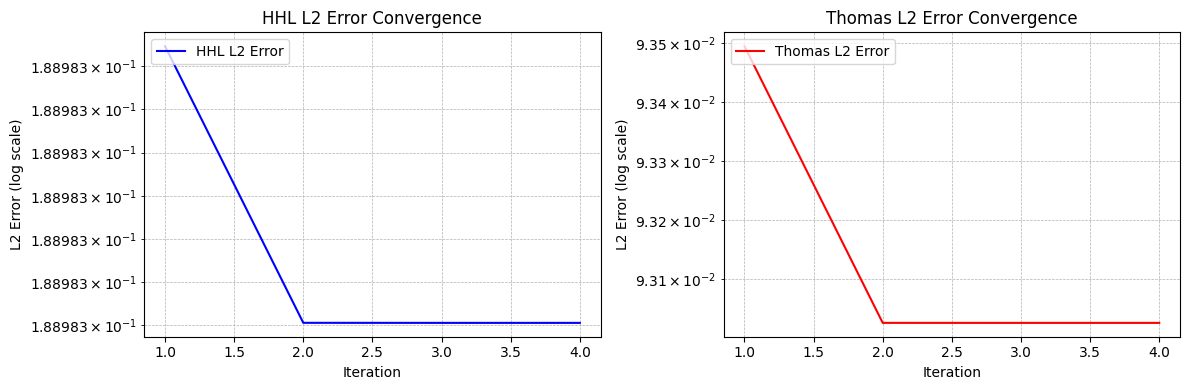

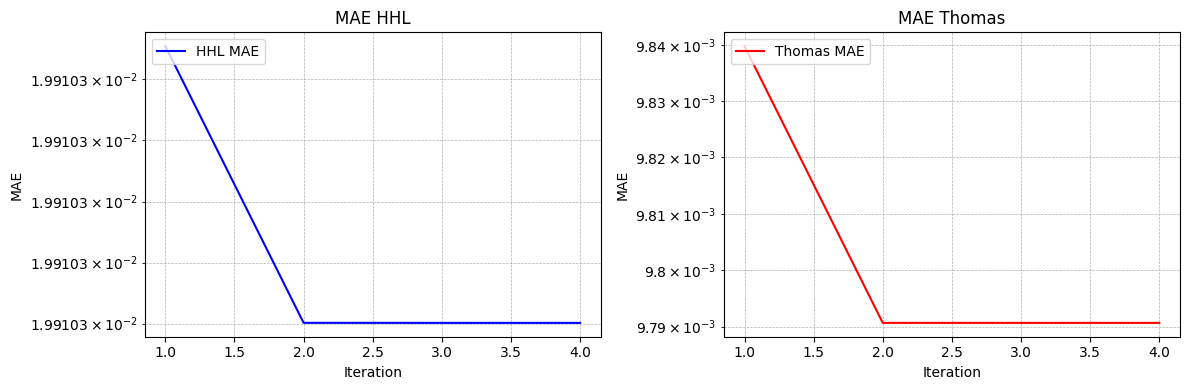

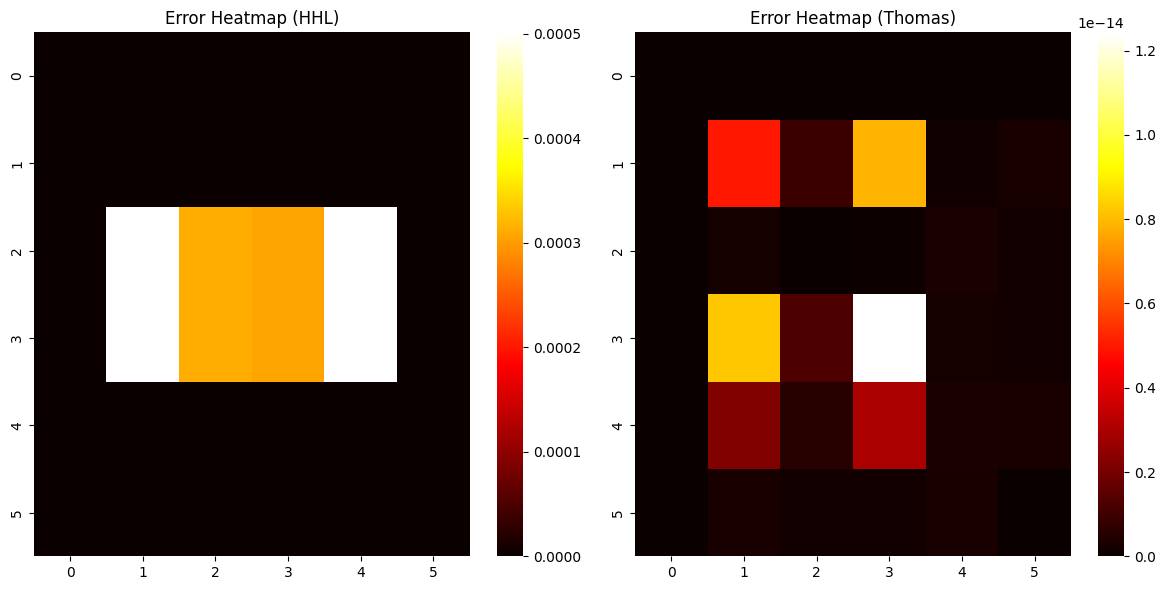

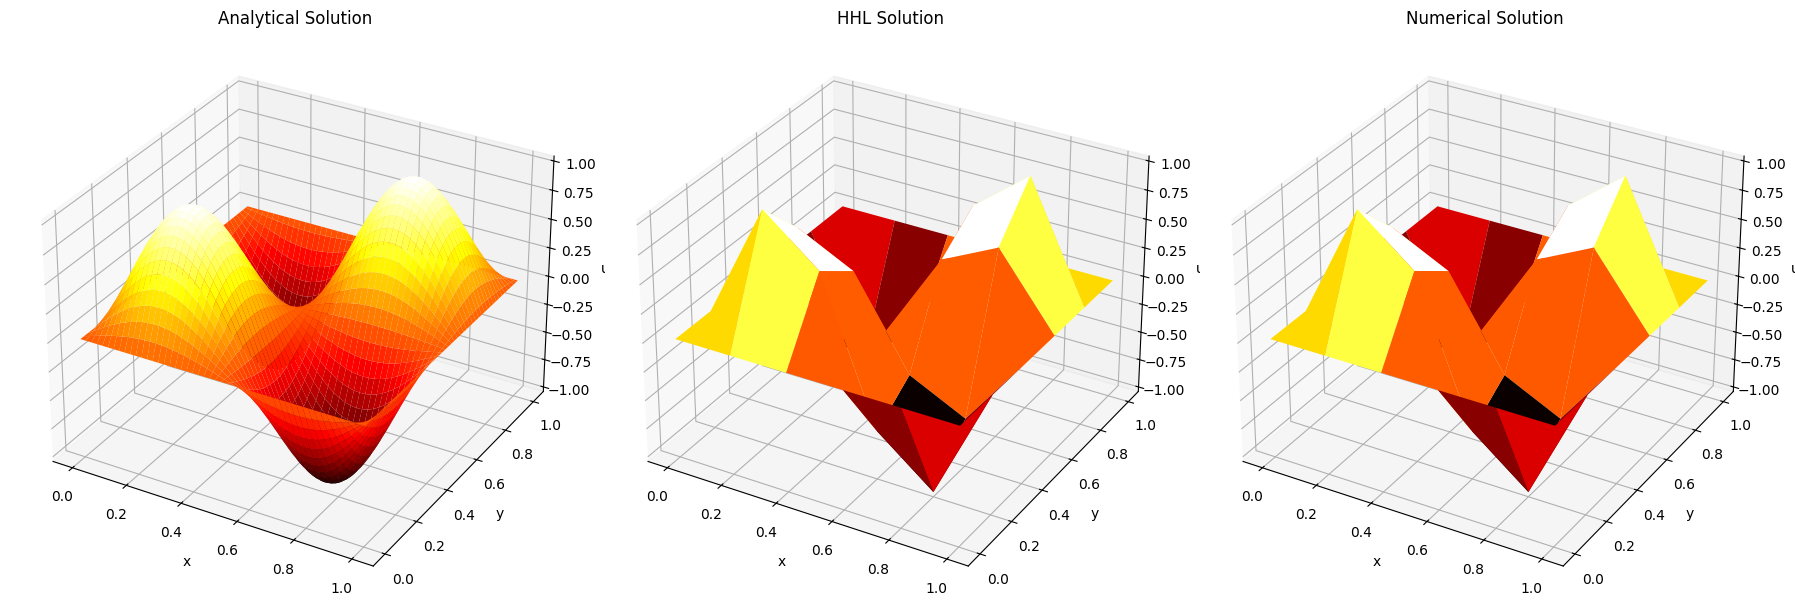

In [92]:
lb, ub = -1.0, 1.0
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
u_tom_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_analytical = normalize(u_analytical, lb, ub)
u_analytical_resampled = normalize(u_analytical_resampled, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

error_hhl_grid = np.abs(u_hhl_padded - u_analytical_resampled)
error_tom_grid = np.abs(u_tom_padded - u_analytical_resampled)

####################################### Final solution #########################################################################
# plot the iteration wise errors
# Plot HHL and Thomas error convergence side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# HHL L2 error convergence
axs[0].plot(range(1, len(errors) + 1), [err[0][0] for err in errors], label='HHL L2 Error', color='b')
axs[0].set_yscale('log')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('L2 Error (log scale)')
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].set_title('HHL L2 Error Convergence')
axs[0].legend(loc='upper left')

# Thomas L2 error convergence
axs[1].plot(range(1, len(errors) + 1), [err[1][0] for err in errors], label='Thomas L2 Error', color='r')
axs[1].set_yscale('log')
axs[1].set_xlabel('Iteration')
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_ylabel('L2 Error (log scale)')
axs[1].set_title('Thomas L2 Error Convergence')
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# subplot of the pct different to the analytical solution
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# HHL L2 error convergence
axs[0].plot(range(1, len(errors) + 1), [err[0][1] for err in errors], label='HHL MAE', color='b')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel('MAE')
axs[0].set_title('MAE HHL')
axs[0].set_yscale('log')
axs[0].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[0].legend(loc='upper left')

# Thomas L2 error convergence
axs[1].plot(range(1, len(errors) + 1), [err[1][1] for err in errors], label='Thomas MAE', color='r')
axs[1].set_xlabel('Iteration')
axs[1].set_yscale('log')
axs[1].grid(True, which='both', linestyle='--', linewidth=0.5)
axs[1].set_ylabel('MAE')
axs[1].set_title('MAE Thomas')
axs[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# subplots of the erros heatmap
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Error Heatmap (HHL)')
sns.heatmap(error_hhl_grid, cmap='hot', cbar=True)
plt.subplot(1, 2, 2)
plt.title('Error Heatmap (Thomas)')
sns.heatmap(error_tom_grid, cmap='hot', cbar=True)
plt.tight_layout()
plt.show()


# plot the 3D surface plots of the solutions side by side using the padded computed solution
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(X_high_res, Y_high_res, u_analytical, cmap='hot')
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_surface(x, y, u_hhl_padded, cmap='hot')
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_surface(x, y, u_tom_padded, cmap='hot')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('u')
ax1.set_title('Analytical Solution')
ax2.set_title('HHL Solution')
ax3.set_title('Numerical Solution')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('u')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('u')
plt.tight_layout()
plt.savefig('figures/2D/2D-validation-sidebyside.png')
plt.show()

# Plot and save each padded surface individually
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X_high_res, Y_high_res, u_analytical, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
plt.tight_layout()
plt.savefig('figures/2D/2D-validation-analytical_solution.png')
plt.close(fig)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, u_hhl_padded, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
plt.tight_layout()
plt.savefig('figures/2D/2D-validation-hhl_solution_padded.png')
plt.close(fig)

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, u_tom_padded, cmap='hot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
plt.tight_layout()
plt.savefig('figures/2D/2D-validation-numerical_solution_padded.png')
plt.close(fig)

# plot the contour plot of the computed solution side by side using the padded computed solution
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
# Analytical solution heatmap
sns.heatmap(u_analytical, cmap='hot', ax=axs[0], cbar=True)
axs[0].set_title('Analytical Solution')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
# HHL computed solution (padded) heatmap
sns.heatmap(u_hhl_padded, cmap='hot', ax=axs[1], cbar=True)
axs[1].set_title('HHL Solution')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
# Numerical computed solution (padded) heatmap
sns.heatmap(u_tom_padded, cmap='hot', ax=axs[2], cbar=True)
axs[2].set_title('Numerical Solution')
axs[2].set_xlabel('x')
axs[2].set_ylabel('y')
plt.tight_layout()
plt.savefig('figures/2D/2D-validation-contour-sidebyside.png')
plt.close(fig)


In [8]:
from matplotlib.pylab import norm


for qubits in [1,2,3]:
    N   = 2**qubits
    h   = 1/(N+1)
    k=2
    a   = -0.5/h**2
    b   =  1 + 1/h**2 + 0.5*k**2

    Ax  = construct_TT_matrix(b,a,N)
    rhs = np.random.randn(N)            # random but fixed seed
    x_np = np.linalg.solve(Ax, rhs)
    th  = solve_1DThomas(Ax,rhs)
    sv  = statevector(solve_1DHHL(Ax,rhs,qubits), qubits, rhs, 1024)
    sv = normalize(sv, min(th), max(th))
    th = normalize(th, min(th), max(th))
    x_np = normalize(x_np, min(th), max(th))
    print("Numpy vs Thomas error:", np.linalg.norm(x_np - th) / np.linalg.norm(x_np))

    print("Numpy vs HHL error:", np.linalg.norm(x_np - sv) / np.linalg.norm(x_np))
    print(qubits, np.linalg.norm(th-sv)/np.linalg.norm(th))


Matrix Condition number: 2.2000000000000006
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  3 Number of b qubits :  1
Numpy vs Thomas error: 0.034821748636772315
Numpy vs HHL error: 0.12246273167844239
1 0.13248440058000913
Matrix Condition number: 6.2029659482445565
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
Numpy vs Thomas error: 0.04151415082658634
Numpy vs HHL error: 1.5458923668229438
2 1.5234621784282414
Matrix Condition number: 20.30655412965227
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  6 Number of b qubits :  3
Numpy vs Thomas error: 0.35911805074926784
Numpy vs HHL error: 1.0975395244060486
3 1.2919099618849046


# Solution Convergence Study :: Disretization

Investigate the impact of discretisation on the solution accuracy when using the ADI method

## Run Simulation

Running mesh convergence study for NUM_QUBITS = 1
Matrix Condition number: 2.2000000000000006
row 0
f i [-62.21762641  62.21762641]
u_hhl [[0. 0.]
 [0. 0.]]
u_thomas [[0. 0.]
 [0. 0.]]
f_i_hhl_mod [-69.13069601  69.13069601]
f_i_thomas_mod [-69.13069601  69.13069601]
ay shift [[12.  -4.5]
 [-4.5 12. ]]
solution_thomas [-4.18973915  4.18973915]
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  3 Number of b qubits :  1
solution hhl [-3.94023136  3.94023136]
row 1
f i [ 62.21762641 -62.21762641]
u_hhl [[-3.94023136  0.        ]
 [ 3.94023136  0.        ]]
u_thomas [[-4.18973915  0.        ]
 [ 4.18973915  0.        ]]
f_i_hhl_mod [ 51.39965489 -51.39965489]
f_i_thomas_mod [ 50.27686982 -50.27686982]
ay shift [[12.  -4.5]
 [-4.5 12. ]]
solution_thomas [ 3.04708302 -3.04708302]
 Number of ancilla qubits :  0  Number of flag qubits :  1  Number of clock qubits :  3 Number of b qubits :  1
solution hhl [ 3.94023136 -3.94023136]
y sweep computed 0.367453813

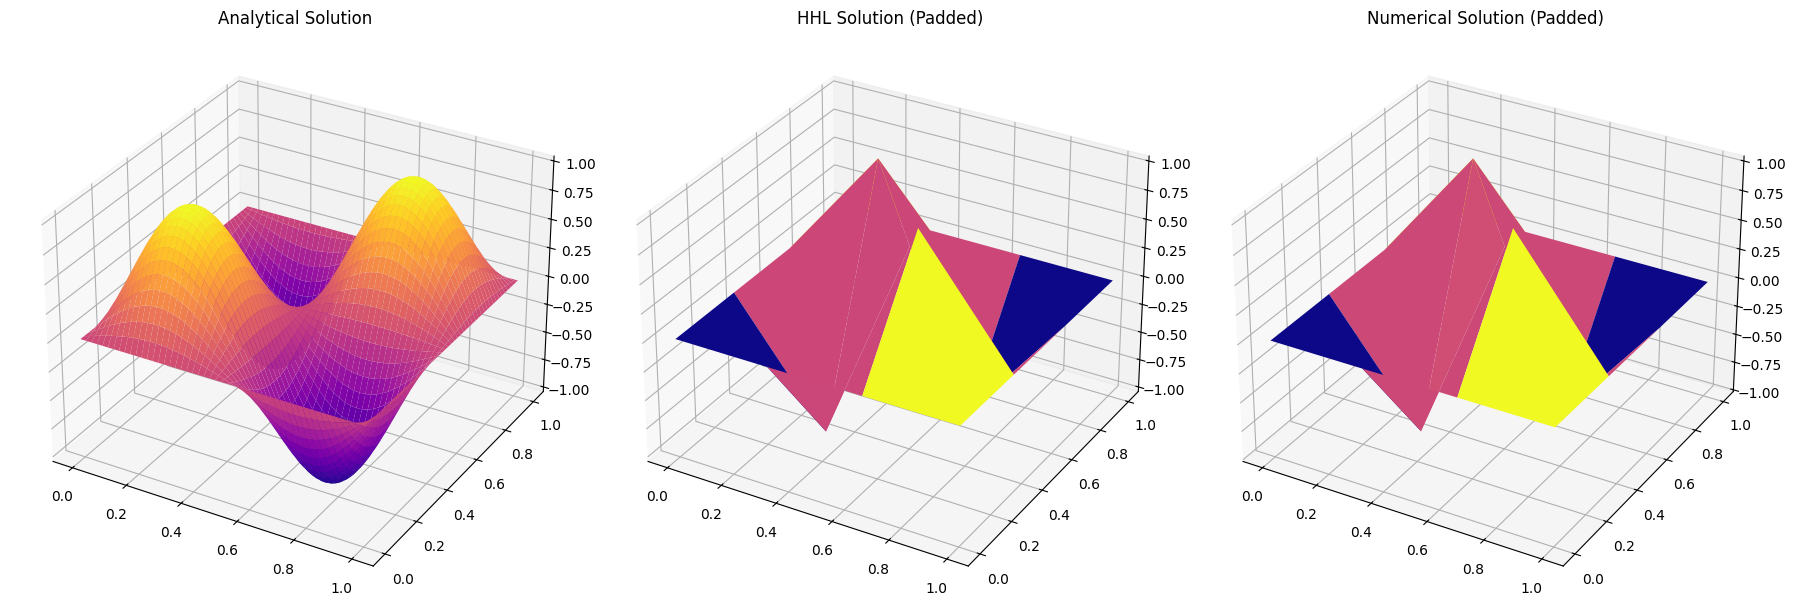

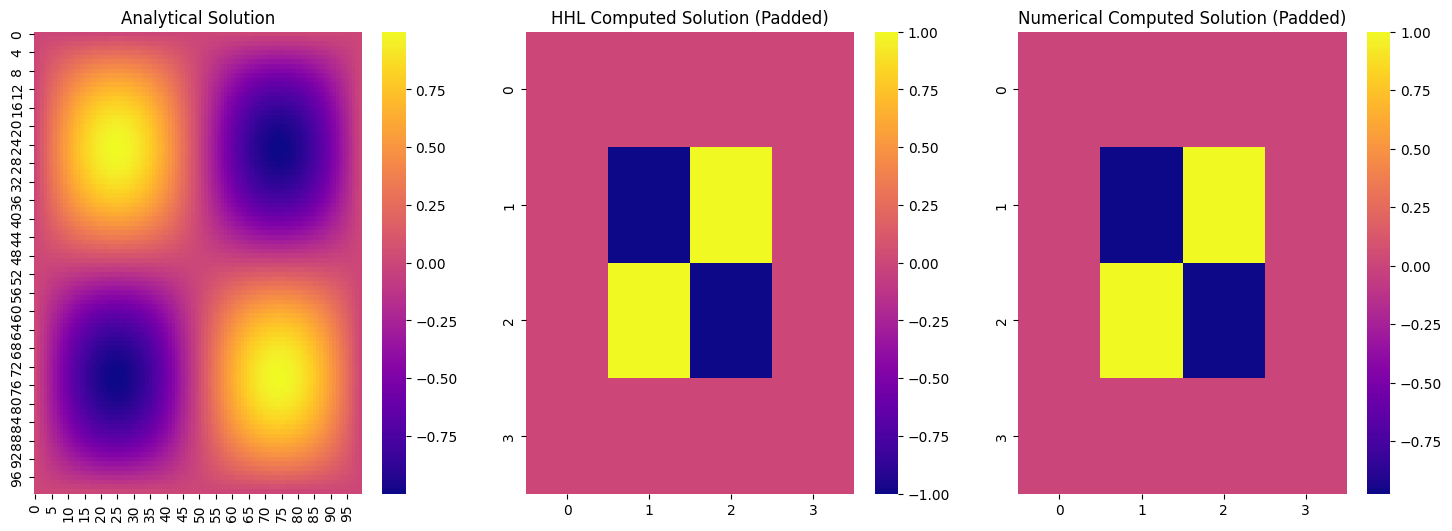

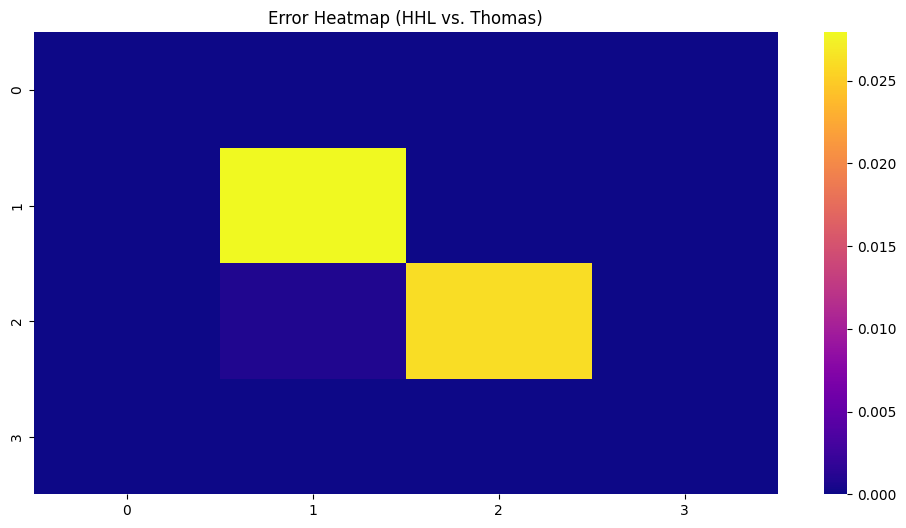

Running mesh convergence study for NUM_QUBITS = 2
Matrix Condition number: 6.2029659482445565
row 0
f i [-75.03516235 -46.37428068  46.37428068  75.03516235]
u_hhl [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
u_thomas [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
f_i_hhl_mod [-78.03656884 -48.22925191  48.22925191  78.03656884]
f_i_thomas_mod [-78.03656884 -48.22925191  48.22925191  78.03656884]
ay shift [[ 26.58578644 -12.5          0.           0.        ]
 [-12.5         26.58578644 -12.5          0.        ]
 [  0.         -12.5         26.58578644 -12.5       ]
 [  0.           0.         -12.5         26.58578644]]
solution_thomas [-4.13759665 -2.55717536  2.55717536  4.13759665]
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  2
solution hhl [-3.88857711 -2.4014149   2.4014149   3.88857711]
row 1
f i [-46.37428068 -28.66088166  28.66088166  46.37428068]
u_hhl [[-3.88857711  0.          0.

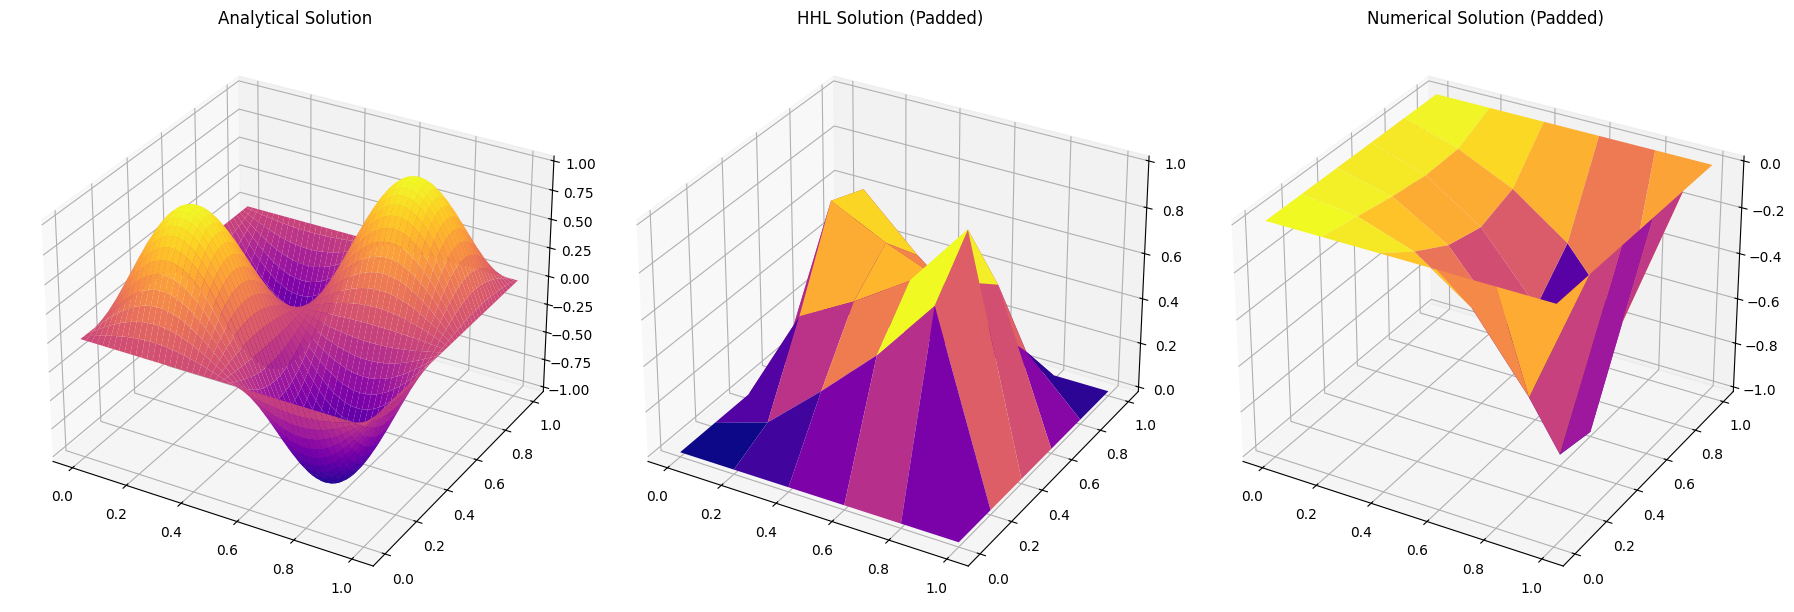

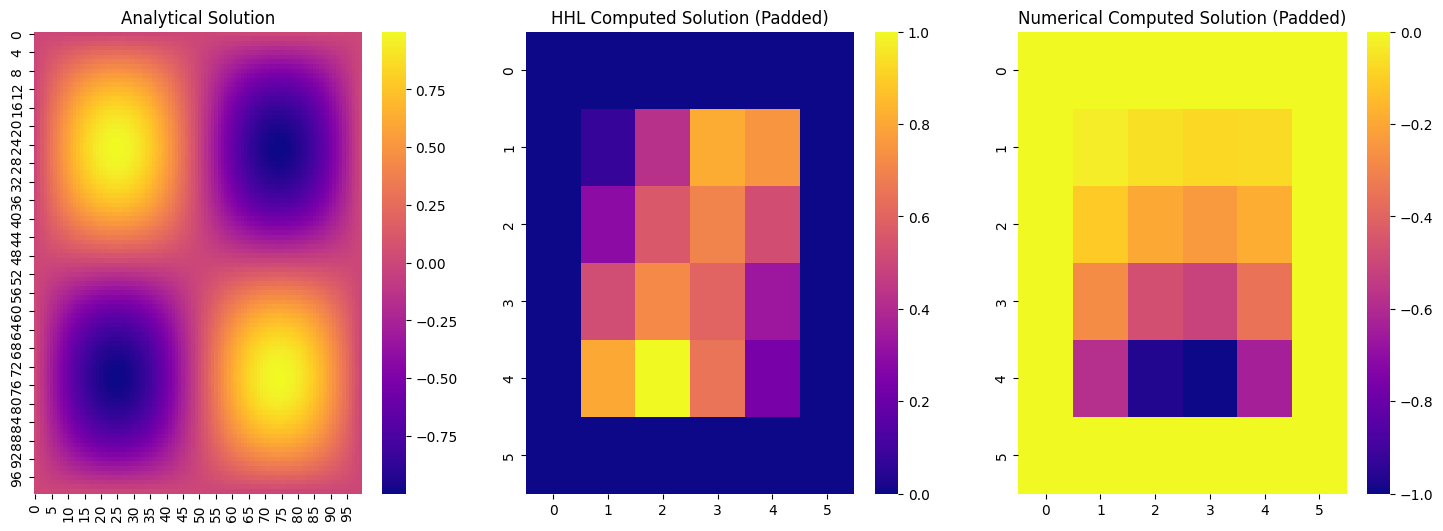

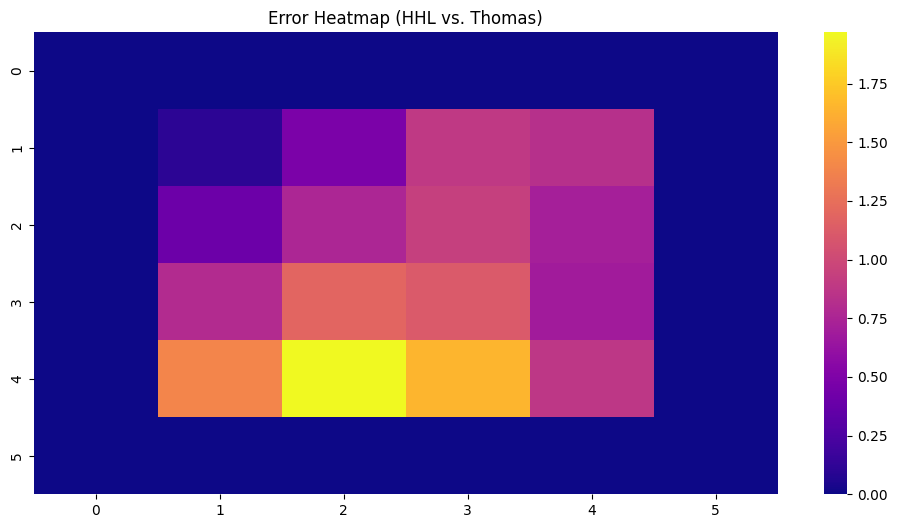

Running mesh convergence study for NUM_QUBITS = 3
Matrix Condition number: 20.30655412965227
row 0
f i [-34.27576597 -52.51352012 -46.17961457 -18.23775414  18.23775414
  46.17961457  52.51352012  34.27576597]
u_hhl [[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
u_thomas [[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
f_i_hhl_mod [-34.69892358 -53.16183518 -46.74973327 -18.4629116   18.4629116
  46.74973327  53.16183518  34.69892358]
f_i_thomas_mod [-34.69892358 -53.16183518 -46.74973327 -18.4629116   18.4629116
  46.74973327  53.16183518  34.69892358]
ay shift [[ 82.15224093 -40.5          0.           0.           0.
    0.           0.           0.  

KeyboardInterrupt: 

In [65]:
# List of qubit counts to test (increase as needed)
qubit_list = [1, 2, 3, 4, 5]
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
k = 2.0              # Wave Number
max_iter = 5
num_shots = 1000

# Dictionary to store the L2 error for each mesh resolution
errors_vs_qubits = {}

for NUM_QUBITS in qubit_list:
    print(f"Running mesh convergence study for NUM_QUBITS = {NUM_QUBITS}")
    N = 2**NUM_QUBITS
    N_total = N + 2
    
    # Define grid spacing and grids
    dx = Lx / (N + 1)
    dy = Ly / (N + 1)
    h = dx  # h assumed same in both directions

    # Create full grid including boundaries
    x_vals = np.linspace(0, Lx, N_total)
    y_vals = np.linspace(0, Ly, N_total)
    x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
    
    # Interior grid points
    interior_x = x_vals[1:-1]
    interior_y = y_vals[1:-1]
    interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')
    
    # Forcing function (evaluated on the interior)
    f_interior = -k**2 * (2 * (np.pi)**2 + 1) * np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)
    
    # High resolution grid for the analytical solution
    X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
    u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res)
    
    # Resampled analytical solution on the computed grid (for error estimation)
    u_analytical_resampled = np.sin(k * np.pi * interior_x) * np.sin(k * np.pi * interior_y)
    
    # Operator matrices
    shift = 2 * np.cos(np.pi / N)  # Shift value for HHL
    sigma = 0.5                      # Douglas choice
    a     = -sigma / h**2            # off–diagonal
    b     =  1 + 2*sigma / h**2 + 0.5*k**2   # main diagonal

    Ax = construct_TT_matrix(main_diag=b, off_diag=a, size=N)
    Ay = Ax.copy()    
    # Initial guess
    u_init = np.zeros((N, N))
    

    # Solve using the ADI statevector validation method
    u_hhl, u_thomas, errors, pct_diff = ADI_val_sv(u_init, Ax, Ay, f_interior, u_analytical_resampled, shift, max_iter=max_iter, numShots=num_shots)

    # Use the errors computed in the last ADI iteration:
    # errors[-1] is a tuple: ((L2_error_HHL, MAE_HHL), (L2_error_Thomas, MAE_Thomas))
    last_error = errors[-1]
    error_hhl = last_error[0]
    error_thomas = last_error[1]
    mae_hhl = last_error[2]
    mae_thomas = last_error[3]
    l2_error = last_error[4]
    
    # Compute the mean percent difference to Thomas from the last iteration
    mean_pct_diff = np.mean(pct_diff[-1])

    # For visualization, pad and normalize the computed solutions (Dirichlet condition)
    u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
    u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
    u_hhl_norm = normalize(u_hhl_padded, -1.0, 1.0)
    u_thomas_norm = normalize(u_thomas_padded, -1.0, 1.0)
    u_analytical_norm = normalize(u_analytical_resampled, -1.0, 1.0)
    
    # Store the computed errors and percent difference in the dictionary
    errors_vs_qubits[NUM_QUBITS] = {
        "L2 Error (Thomas)": error_thomas,
        "L2 Error (HHL)": error_hhl,
        "MAE (Thomas)": mae_thomas,
        "MAE (HHL)": mae_hhl,
        "Mean Percent Difference to Thomas": mean_pct_diff,
        "L2 Error": l2_error,
    }
    print()
    print(f"NUM_QUBITS = {NUM_QUBITS}: L2 Error (HHL) = {l2_error}, Mean Percent Difference to Thomas = {mean_pct_diff}")
    print()
    

    
    visualize(x, y, X_high_res, Y_high_res, u_analytical, u_hhl_norm, u_thomas_norm)



## Plot Results

[1.3742292001556224, 0.6731810399382889, 0.5635423960043351]


<Figure size 600x400 with 0 Axes>

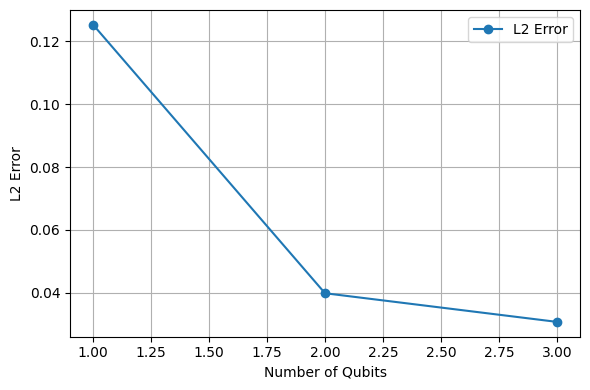

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

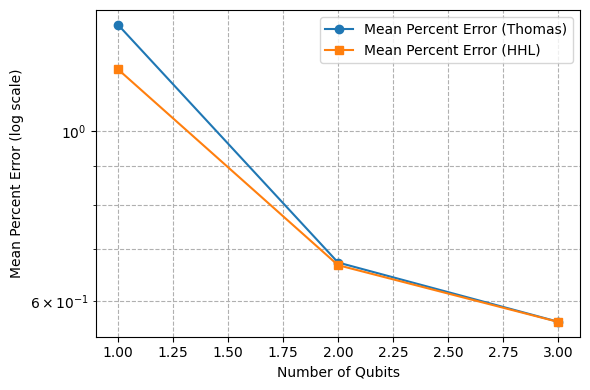

Log Gradient for Mean Percent Error (Thomas): -0.4457028518207373
Log Gradient for Mean Percent Error (HHL): -0.37906282018907667
Log Gradient for L2 Error (Thomas): -0.7018745224155681


In [8]:

# Optionally, plot the convergence
plt.figure(figsize=(6,4))
# Extract L2 errors for Thomas and HHL solutions
qubits = list(errors_vs_qubits.keys())
l2_errors_thomas = [errors_vs_qubits[q]["L2 Error (Thomas)"] for q in qubits]
l2_errors_hhl = [errors_vs_qubits[q]["L2 Error (HHL)"] for q in qubits]
pct_errors_thomas = [errors_vs_qubits[q]["MAE (Thomas)"] for q in qubits]
pct_errors_hhl = [errors_vs_qubits[q]["MAE (HHL)"] for q in qubits]
l2_errors = [errors_vs_qubits[q]["L2 Error"] for q in qubits]
print(pct_errors_thomas)

# Plot the L2 errors
plt.figure(figsize=(6, 4))
plt.plot(qubits, l2_errors, marker='o', label='L2 Error')
plt.xlabel("Number of Qubits")
plt.ylabel("L2 Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/2D/mesh-conv-L2_Error_vs_Qubits.png')
plt.show()

# Plot the mean percent errors in log scale
plt.figure(figsize=(6, 4))
plt.plot(qubits, pct_errors_thomas, marker='o', label='Mean Percent Error (Thomas)')
plt.plot(qubits, pct_errors_hhl, marker='s', label='Mean Percent Error (HHL)')
plt.yscale('log')
plt.xlabel("Number of Qubits")
plt.ylabel("Mean Percent Error (log scale)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.savefig('figures/2D/mesh-conv-Mean_Percent_Error_vs_Qubits_Log_Scale.png')
plt.show()


# Compute the log-gradient of the percent errors with respect to the number of qubits.# Compute the log-gradient of the percent errors with respect to the number of qubits.# Compute the log-gradient of the percent errors with respect to the number of qubits.# Compute the log-gradient of the percent errors with respect to the number of qubits.
qubits_arr = np.array(qubits)

# Convert percent errors lists to numpy arrays and take the natural log
log_pct_errors_thomas = np.log(np.array(pct_errors_thomas))
log_pct_errors_hhl = np.log(np.array(pct_errors_hhl))

# Compute the gradient of the log percent errors
grad_pct_errors_thomas = np.gradient(log_pct_errors_thomas, qubits_arr)
grad_pct_errors_hhl = np.gradient(log_pct_errors_hhl, qubits_arr)

print("Log Gradient for Mean Percent Error (Thomas):", np.mean(grad_pct_errors_thomas))
print("Log Gradient for Mean Percent Error (HHL):", np.mean(grad_pct_errors_hhl))

# gradient of the l2 errors
log_l2_errors_thomas = np.log(np.array(l2_errors))

grad_l2_errors_thomas = np.gradient(log_l2_errors_thomas, qubits_arr)
print("Log Gradient for L2 Error (Thomas):", np.mean(grad_l2_errors_thomas))


# Solution ADI Iteration Convergence study
How does the number of steps influence the solution accuracy?

## Run Simulation

In [62]:
# Define the range of ADI iterations to test
max_iter_values = 5
NUM_QUBITS = 2  # Number of qubits used to represent the solution

errors_hhl = []
errors_thomas = []

print(f"Running ADI convergence study for NUM_QUBITS = {NUM_QUBITS}")
N = 2**NUM_QUBITS
N_total = N + 2
Lx, Ly = 1.0, 1.0  # Length of the x and y dimensions
k  = 2.0  # Wave Number
num_shots = 2000  # Number of shots for HHL simulation

# Define grid spacing and grids
dx = Lx / (N + 1)
dy = Ly / (N + 1)
h = dx  # h assumed same in both directions

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

# Interior grid points
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# Forcing function (evaluated on the interior)
f_interior = (k - 2 * k**2 * np.pi**2) * np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)

# High resolution grid for the analytical solution
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res)

# Resampled analytical solution on the computed grid (for error estimation)
u_analytical_resampled = np.sin(k * np.pi * x) * np.sin(k * np.pi * y)

# Operator matrices
main_diag = -4/h**2 + k**2
off_diag = 1/h**2
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Initial guess
u_init = np.zeros((N, N))
shift = 2 * np.cos(np.pi / N) # Shift value for HHL

# Solve using the ADI statevector validation method
u_hhl, u_thomas, errors, pct_diff = ADI_val_sv(u_init, Ax, Ay, f_interior, u_analytical_resampled, shift, max_iter=max_iter_values, numShots=num_shots)

Running ADI convergence study for NUM_QUBITS = 2
Matrix Condition number: 2.4563985052494743
Iteration: 0
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
Row (x-sweep) completed in: 4.05997896194458
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Number of clock qubits :  4 Number of b qubits :  2
 Number of ancilla qubits :  1  Number of flag qubits :  1  Numbe

In [60]:
print(errors)

[(2.7992299022585846e-05, 2.842955311518902e-05), (5.298419043317823e-06, 9.692717460442324e-09), (5.3012418209081996e-06, 2.6116917270810644e-12), (5.301241069281044e-06, 6.183325456592886e-16), (5.301241068752145e-06, 2.929755203871941e-17), (5.30124106874752e-06, 2.929755203871941e-17), (5.30124106874752e-06, 2.929755203871941e-17), (5.30124106874752e-06, 2.929755203871941e-17), (5.30124106874752e-06, 2.929755203871941e-17), (5.30124106874752e-06, 2.929755203871941e-17)]


## Plot Results

<Figure size 600x400 with 0 Axes>

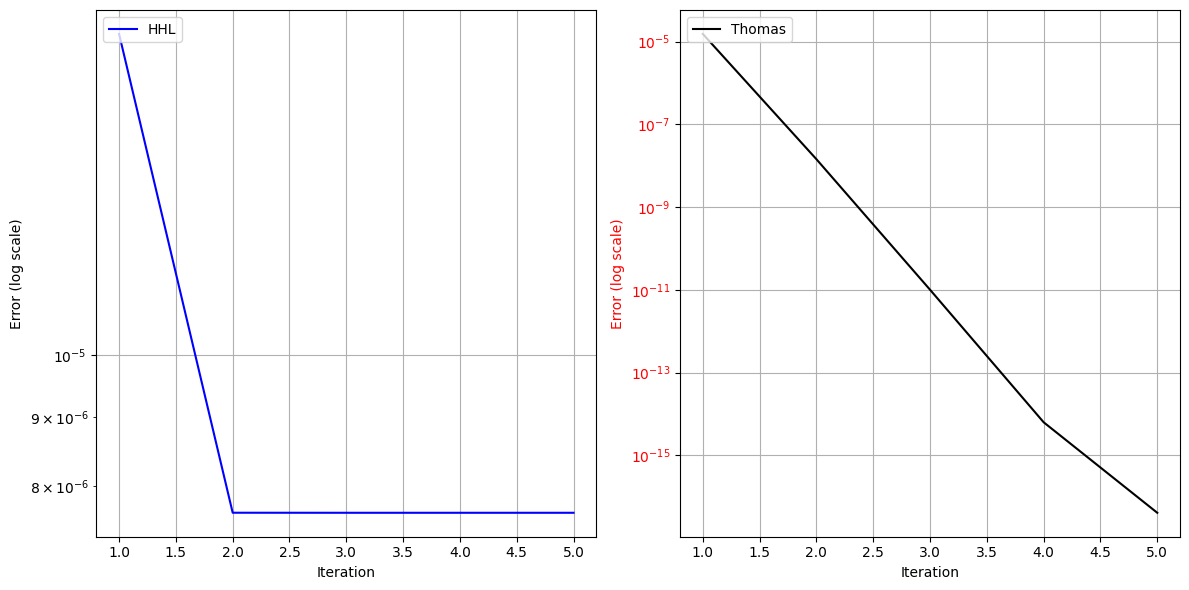

Gradient of log(HHL errors): -0.24325746751387936
Gradient of log(Thomas errors): -6.530464371167715
Gradient of log(Mean Percent Difference): -1.0043819345817439e-05


In [75]:
import numpy as np

# plot the iteration wise errors
plt.figure(figsize=(6, 4))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot errors on the primary y-axis in the first subplot
ax1.plot(range(1, len(errors) + 1), [err[0] for err in errors], label='HHL', color='b')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Error (log scale)', color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.legend(loc='upper left')
ax1.grid(True)

# Plot percent difference on the second subplot
ax2.plot(range(1, len(errors) + 1), [err[1] for err in errors], label='Thomas', color='k')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Error (log scale)', color='r')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='r')
ax2.legend(loc='upper left')
ax2.grid(True)

fig.tight_layout()
plt.savefig('figures/2D/2D-validation-iterationwise-errors-sidebyside.png')
plt.show()

hhl_errors = np.array([err[0] for err in errors])
thomas_errors = np.array([err[1] for err in errors])
pct_diff_means = np.array([np.mean(diff) for diff in pct_diff])

grad_hhl = np.gradient(np.log(hhl_errors))
grad_thomas = np.gradient(np.log(thomas_errors))
grad_pct = np.gradient(np.log(pct_diff_means))

print("Gradient of log(HHL errors):", np.mean(grad_hhl))
print("Gradient of log(Thomas errors):", np.mean(grad_thomas))
print("Gradient of log(Mean Percent Difference):", np.mean(grad_pct))



# Solution ADI Shift Parameter 
Investigate the impact of the shift parameter on accuracy,
Results: There is very little impact of this parameter on the solution accuracy.

## Run Simulation

In [64]:
# List of shift values to test (investigation on the shift parameter)
shift_list = np.linspace(1, 5, 5)  # adjust range/number as needed
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
k = 2.0              # Wave Number
max_iter = 5
num_shots = 1000

# We'll use a fixed qubit count for this study
NUM_QUBITS = 3
N = 2**NUM_QUBITS
N_total = N + 2

# Define grid spacing and grids
dx = Lx / (N + 1)
dy = Ly / (N + 1)
h = dx  # assume same spacing in both directions

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')

# Interior grid points
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# Forcing function (evaluated on the interior)
f_interior = (k - 2 * k**2 * np.pi**2) * np.sin(k * np.pi * interior_X) * np.sin(k * np.pi * interior_Y)

# High resolution grid for the analytical solution
X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, 100), np.linspace(0, Ly, 100), indexing='ij')
u_analytical = np.sin(k * np.pi * X_high_res) * np.sin(k * np.pi * Y_high_res)

# Resampled analytical solution on the computed grid (for error analysis)
u_analytical_resampled = np.sin(k * np.pi * x) * np.sin(k * np.pi * y)

# Operator matrices
main_diag = -4/h**2 + k**2
off_diag = 1/h**2
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Dictionary to store errors for each shift value
errors_vs_shift = {}

for shift in shift_list:
    print(f"Running shift study for shift = {shift}")
    # Initial guess
    u_init = np.zeros((N, N))
    
    # Solve using the ADI statevector validation method
    u_hhl, u_thomas, errors, pct_diff = ADI_val_sv(u_init, Ax, Ay, f_interior, u_analytical_resampled, shift,
                                                    max_iter=max_iter, numShots=num_shots)

    # Pad the solutions for error estimation
    u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
    u_thomas_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
    u_hhl_norm = normalize(u_hhl_padded, -1.0, 1.0)
    u_thomas_norm = normalize(u_thomas_padded, -1.0, 1.0)
    u_analytical_norm = normalize(u_analytical_resampled, -1.0, 1.0)
    
    # Compute the L2 error for Thomas and HHL solutions
    error_thomas = np.linalg.norm(u_thomas_norm - u_analytical_norm)
    error_hhl = np.linalg.norm(u_hhl_norm - u_analytical_norm)
    
    # Use last iteration's percent difference and error values for reporting
    mean_pct_diff = abs(np.mean(pct_diff[-1]))
    last_error = errors[-1]
    
    errors_vs_shift[shift] = {
        "L2 Error (Thomas)": error_thomas,
        "L2 Error (HHL)": error_hhl,
        "Mean Percent Difference to Thomas": mean_pct_diff,
        "Mean Percent Error (Thomas)": last_error[1],
        "Mean Percent Error (HHL)": last_error[0],
    }
    
    print(f"shift = {shift}: L2 Error (Thomas) = {error_thomas}, "
          f"L2 Error (HHL) = {error_hhl}, Mean Percent Difference = {mean_pct_diff}")
    
    #visualize(x, y, X_high_res, Y_high_res, u_analytical, u_hhl_norm, u_thomas_norm)


Matrix Condition number: 2.8147510304189294
Running shift study for shift = 1.0
Iteration: 0
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
 Number of ancilla qubits :  2  Number of flag qubits :  1  Number of clock qubits :  5 Number of b qubits :  3
Row (x-swee

## Plot Results

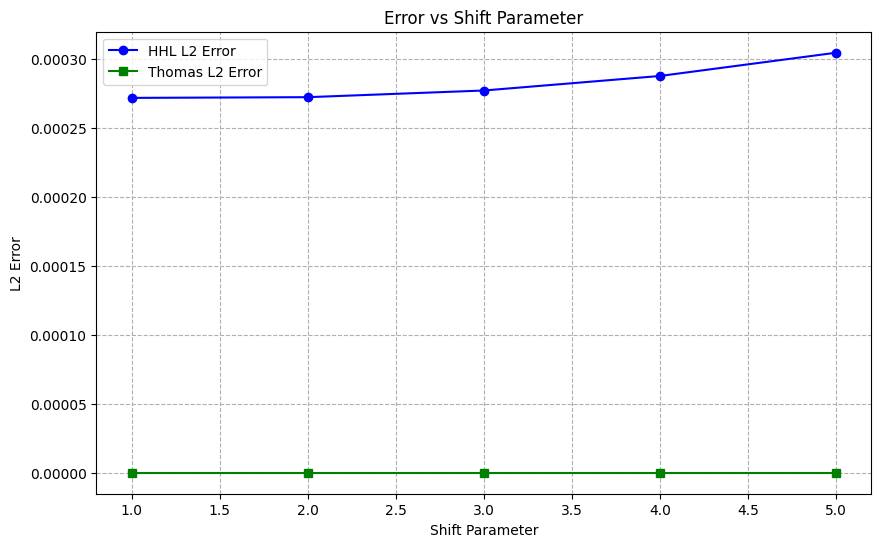

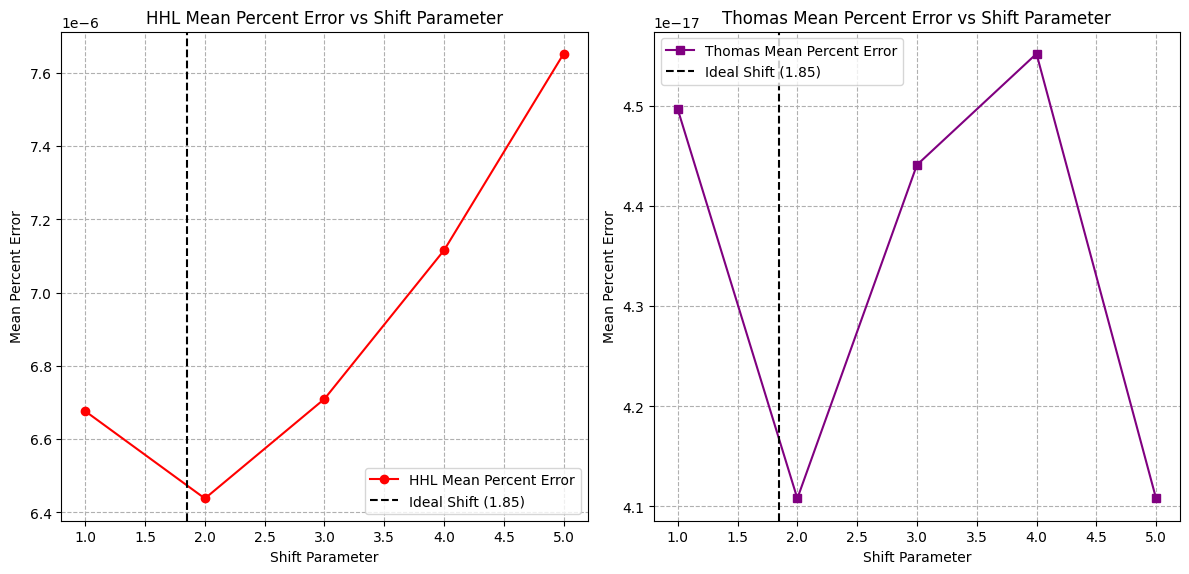

In [73]:
# Analyze and visualize the results
# Plot the error for different shift parameters
shift_values = list(errors_vs_shift.keys())
hhl_errors = [errors_vs_shift[shift]["L2 Error (HHL)"] for shift in shift_values]
thomas_errors = [errors_vs_shift[shift]["L2 Error (Thomas)"] for shift in shift_values]

plt.figure(figsize=(10, 6))
plt.plot(shift_values, hhl_errors, label='HHL L2 Error', marker='o', color='blue')
plt.plot(shift_values, thomas_errors, label='Thomas L2 Error', marker='s', color='green')
plt.xlabel('Shift Parameter')
plt.ylabel('L2 Error')
plt.title('Error vs Shift Parameter')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# Plot the mean percent error for HHL and Thomas vs shift
hhl_mean_percent_error = [errors_vs_shift[shift]["Mean Percent Error (HHL)"] for shift in shift_values]
thomas_mean_percent_error = [errors_vs_shift[shift]["Mean Percent Error (Thomas)"] for shift in shift_values]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot Mean Percent Error for HHL
axs[0].plot(shift_values, hhl_mean_percent_error, label='HHL Mean Percent Error', marker='o', color='red')
ideal_shift = 2 * np.cos(np.pi / N)
axs[0].axvline(ideal_shift, color='black', linestyle='--', label=f'Ideal Shift ({ideal_shift:.2f})')
axs[0].set_xlabel('Shift Parameter')
axs[0].set_ylabel('Mean Percent Error')
axs[0].set_title('HHL Mean Percent Error vs Shift Parameter')
axs[0].legend()
axs[0].grid(True, which="both", ls="--")

# Plot Mean Percent Error for Thomas
axs[1].plot(shift_values, thomas_mean_percent_error, label='Thomas Mean Percent Error', marker='s', color='purple')
ideal_shift = 2 * np.cos(np.pi / N)
axs[1].axvline(ideal_shift, color='black', linestyle='--', label=f'Ideal Shift ({ideal_shift:.2f})')
axs[1].set_xlabel('Shift Parameter')
axs[1].set_ylabel('Mean Percent Error')
axs[1].set_title('Thomas Mean Percent Error vs Shift Parameter')
axs[1].legend()
axs[1].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()


# Solution Testing :: GAUSS :: confirmed working

Define solution and ADI parameters

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)
h = dx

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 10.0  # Wave Number
main_diag = -4/dx**2 + k**2  # main diagonal
off_diag = 1/dx**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='gaussian', x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")

# get psuedo
u_analytic_high_res, X_high_res, Y_high_res = prepare_pseudoanalytic(Lx, Ly, k, N_high_res=100, type='gaussian')


Call the ADI now

In [ ]:
u_init = np.zeros((N,N))

# Solve using the ADI now in quantum
backend = Aer.get_backend('qasm_simulator')
backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }

#u_hhl, u_tom, errors, pct_diff = ADI_qasm(u_init, Ax, Ay, f_grid, backend, backend_options, max_iter=3)
u_hhl, u_tom, pct_diff = ADI_sv_prec(u_init, Ax, Ay, f_grid,h,k, alpha=0.2, max_iter=3)

In [ ]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
lb, ub= -1.0,1.0
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = np.pad(u_tom, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

visualize(x, y, X_high_res, Y_high_res, -u_analytic_high_res, -u_hhl_padded, -u_tom_padded, cmap='hot')

# plot eerrors
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(range(1, len(errors) + 1), [err for err in errors], 'o-', label='L2 difference ', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('L2 Error (log scale)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a twin y-axis for percent difference
ax2 = ax1.twinx()
ax2.plot(range(1, len(pct_diff) + 1), [np.mean(diff) for diff in pct_diff], 's--', color='red', label='Mean Pct Diff')
ax2.set_ylabel('Mean Percent Difference', color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Error Convergence')
plt.tight_layout()
plt.show()

## Solution Testing :: UNIF

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N + 2    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 10.0  # Wave Number
main_diag = -4/h**2 + k**2  # main diagonal
off_diag = 1/h**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='uniform', amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")

# get psuedo
u_analytic_high_res, X_high_res, Y_high_res = prepare_pseudoanalytic(Lx, Ly, k, N_high_res=100, type='uniform')

In [ ]:
u_init = np.zeros((N,N))
# Solve using the ADI now in quantum
u_hhl, u_thomas, pct_diff =  ADI_sv_prec(u_init, Ax, Ay, f_grid,h, k, alpha = 0.1, max_iter = 4)

In [ ]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
lb, ub= -1.0,1.0
x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = np.pad(u_thomas, pad_width=1, mode='constant', constant_values=0)
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = np.pad(u_hhl, pad_width=1, mode='constant', constant_values=0)
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

u_analytical = normalize(u_analytical, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

visualize(x, y, X_high_res, Y_high_res, -u_analytic_high_res, -u_hhl_padded, -u_tom_padded, cmap='hot')

# plot eerrors
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(range(1, len(errors) + 1), [err for err in errors], 'o-', label='L2 difference ', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('L2 Error (log scale)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a twin y-axis for percent difference
ax2 = ax1.twinx()
ax2.plot(range(1, len(pct_diff) + 1), [np.mean(diff) for diff in pct_diff], 's--', color='red', label='Mean Pct Diff')
ax2.set_ylabel('Mean Percent Difference', color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Error Convergence')
plt.tight_layout()
plt.show()

## Neumann Boundary Conditions
Assess and validate if the neumann b-c have been implemented correctly.

In [ ]:
def prepare_pseudoanalytic_neumann(Lx, Ly, k, N_high_res=100, type = 'gaussian'):
    """
    Prepare a pseudo-analytic solution using the ADI method with higher resolution.

    Parameters:
        f_high_grid : numpy.ndarray
            Forcing function grid at higher resolution.
        Lx, Ly : float
            Domain lengths in x and y directions.
        k : float
            Wave number for the Helmholtz equation.
        y_grid : numpy.ndarray
            Grid points in the y-direction.
        function : str, optional
            Description of the function being prepared (default is "Solution").
        N_high_res : int, optional
            Higher resolution grid size (default is 100).

    Returns:
        u_analytic_high_res : numpy.ndarray
            Pseudo-analytic solution at higher resolution.
        X_high_res, Y_high_res : numpy.ndarray
            Meshgrid of x and y coordinates at higher resolution.
    """
    # Define higher resolution parameters
    dx_high_res = Lx / (N_high_res + 1)
    dy_high_res = Ly / (N_high_res + 1)
    h_high_res = dx_high_res

    # Reconstruct the operator matrices for higher resolution
    main_diag_high_res = -4 / h_high_res**2 + k**2
    off_diag_high_res = 1 / h_high_res**2
    Ax_high_res = construct_TT_matrix(main_diag=main_diag_high_res, off_diag=off_diag_high_res, size=N_high_res)
    Ay_high_res = Ax_high_res

    # Generate the forcing function for higher resolution
    if type == 'gaussian':
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type=type, x0=Lx/2, y0=Ly/2, sigma=0.1, amplitude=1.0
        )
    elif type == 'uniform':
        # Generate the forcing function for higher resolution
        _, f_high_res_grid, _, _ = generate_forcing_function(
            N_high_res, N_high_res, Lx, Ly, forcing_type='uniform', value=1.0
        )
    else:
        print('Invalid selection of forcing function type.')
        return None

    
    # Initialize the solution for higher resolution
    u_init_high_res = np.zeros((N_high_res, N_high_res))

    # Solve using the ADI method with the Thomas algorithm
    u_high_res_tom = ADI_neumann_general(u_init_high_res, Ax_high_res, Ay_high_res, f_high_res_grid)

    # Generate the high-resolution grid for visualization
    X_high_res, Y_high_res = np.meshgrid(np.linspace(0, Lx, N_high_res), np.linspace(0, Ly, N_high_res), indexing='ij')

    return u_high_res_tom, X_high_res, Y_high_res

def ADI_neumann_general(u, Ax, Ay, f_interior, max_iter=4):
    fun_start = time.time()
     # Build modified (Neumann) operators for the boundaries.
    # Here we assume that for a standard second-derivative discretization the interior
    # operator has off-diagonals = 1/h^2 (for example). At a Neumann boundary the ghost
    # point is replaced by the adjacent interior value and the off-diagonal should be doubled.
    Ax_neumann = Ax.copy()
    Ay_neumann = Ay.copy()
    Ax_neumann[0, 1] = 2 * Ax[0, 1]
    Ax_neumann[-1, -2] = 2 * Ax[-1, -2]
    Ay_neumann[0, 1] = 2 * Ay[0, 1]
    Ay_neumann[-1, -2] = 2 * Ay[-1, -2]

    Ax_neumann = 0.5 * (Ax_neumann + Ax_neumann.T)
    Ay_neumann = 0.5 * (Ay_neumann + Ay_neumann.T)

 

    # Initialize copies for the HHL and Thomas solutions
    u_thomas = u.copy()

    iter_count = 0
    while iter_count < max_iter:
        print(f'Iteration: {iter_count}')

        # 1) X-implicit, Y-explicit sweep (solve along rows)
        start = time.time()
        for j in range(N):
            f_j = f_interior[j, :].copy()

            # Modify neighbor absorption for Neumann boundaries:
            # For interior rows: use the row above and below.
            # For boundaries, reflect the neighbor (i.e. use the adjacent interior row).
            if j == 0:
                # At the bottom boundary (j=0) there is no row below so we reflect using row 1.
                bottom_row_thomas = u_thomas[j + 1, :]
                # In this case we also reflect for the top neighbor (only one neighbor exists).
                top_row_thomas = u_thomas[j + 1, :]
            elif j == N - 1:
                # At the top boundary (j=N-1) there is no row above; reflect using row N-2.
                top_row_thomas = u_thomas[j - 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]
            else:
                top_row_thomas = u_thomas[j + 1, :]
                bottom_row_thomas = u_thomas[j - 1, :]

            # Adjust the forcing term to account for neighbors.
            f_j_thomas = f_j - top_row_thomas - bottom_row_thomas

            # Choose the operator and solver:
            # If on a boundary row, use the Neumann operator and a dense solver.
            if j == 0 or j == N - 1:
                operator = Ax_neumann
                solution_thomas = np.linalg.solve(operator, f_j_thomas)
            else:
                operator = Ax
                solution_thomas = solve_1DThomas(operator, f_j_thomas)

            
            u_thomas[j, :] = solution_thomas

        print('Columns computed in:', time.time() - start)

        # 2) Y-implicit, X-explicit sweep (solve along columns)
        start = time.time()
        for i in range(N):
            f_i = f_interior[:, i].copy()

            # For the x-direction neighbors, apply similar reflection for Neumann BC.
            if i == 0:
                left_col_thomas = u_thomas[:, i + 1]
                right_col_thomas = u_thomas[:, i + 1]
            elif i == N - 1:
                right_col_thomas = u_thomas[:, i - 1]
                left_col_thomas = u_thomas[:, i - 1]
            else:
                left_col_thomas = u_thomas[:, i - 1]
                right_col_thomas = u_thomas[:, i + 1]

            f_i_thomas = f_i - left_col_thomas - right_col_thomas

            if i == 0 or i == N - 1:
                operator = Ay_neumann
                solution_thomas = np.linalg.solve(operator, f_i_thomas)
            else:
                operator = Ay
                solution_thomas = solve_1DThomas(operator, f_i_thomas)

            
            u_thomas[:, i] = solution_thomas

        print('Rows computed in:', time.time() - start)

        
        iter_count += 1

    print('ADI run time:', time.time() - fun_start)
    return u_thomas

Define the domain

In [ ]:
# Domain specifications
Lx = 1.0       # Length of the x-dimension
Ly = 1.0       # Length of the y-dimension
NUM_QUBITS = 3 # Number of qubits used to represent the solution
N = 2**NUM_QUBITS  # Number of interior grid points in each dimension
N_total = N    # Total grid points including boundaries

dx = Lx / (N + 1)  # Grid spacing (consistent with N interior points)
dy = Ly / (N + 1)

# Create full grid including boundaries
x_vals = np.linspace(0, Lx, N_total)
y_vals = np.linspace(0, Ly, N_total)

# Extract interior points (excluding boundaries)
interior_x = x_vals[1:-1]
interior_y = y_vals[1:-1]
interior_X, interior_Y = np.meshgrid(interior_x, interior_y, indexing='ij')

# PDE specifications
k = 1.0  # Wave Number
main_diag = -4/h**2 + k**2  # main diagonal
off_diag = 1/h**2   # off diagonal
Ax = construct_TT_matrix(main_diag=main_diag, off_diag=off_diag, size=N)
Ay = Ax

# Build the forcing function
f, f_grid, x_grid, y_grid = generate_forcing_function(N, N, Lx, Ly, forcing_type='uniform', amplitude=1.0)
# Visualise forcing function
plot_forcing_function(f_grid, x_grid, y_grid, title="Forcing Function")

# get psuedo
u_analytic_high_res, X_high_res, Y_high_res = prepare_pseudoanalytic_neumann(Lx, Ly, k, N_high_res=100, type='uniform')

Call to solvers

In [ ]:
from turtle import back


u_init = np.zeros((N,N))

# Solve using the ADI now in quantum
backend = Aer.get_backend('qasm_simulator')
backend_options = {
    'max_parallel_threads': 8,      # use up to 4 threads
    'max_parallel_experiments': 16,    # run up to 2 experiments in parallel
    'seed_simulator': 42,            # set a seed for reproducibility
    }

u_hhl, u_thomas, errors, pct_diff_list = ADI_neumann(u_init, Ax, Ay, f_grid, backend, backend_options, max_iter=3)

Visualize

In [ ]:
####################################### Final solution #########################################################################
# Pad the computed solution with a boundary of zeros (Dirichlet condition)
lb, ub= -1.0,1.0

x, y = np.meshgrid(x_vals, y_vals, indexing='ij')
u_tom_padded = u_thomas
u_tom_padded = normalize(u_tom_padded, lb, ub)

u_hhl_padded = u_hhl
u_hhl_padded = normalize(u_hhl_padded, lb, ub)

u_analytic_high_res = normalize(u_analytic_high_res, lb, ub)

####################################### Final solution #########################################################################
# subplots of the erros heatmap

visualize(x, y, X_high_res, Y_high_res, -u_analytic_high_res, -u_hhl_padded, -u_tom_padded, cmap='hot')

# plot eerrors
plt.figure(figsize=(10, 6))
ax1 = plt.gca()
ax1.plot(range(1, len(errors) + 1), [err for err in errors], 'o-', label='L2 difference ', color='blue')
ax1.set_yscale('log')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('L2 Error (log scale)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Create a twin y-axis for percent difference
ax2 = ax1.twinx()
ax2.plot(range(1, len(pct_diff) + 1), [np.mean(diff) for diff in pct_diff], 's--', color='red', label='Mean Pct Diff')
ax2.set_ylabel('Mean Percent Difference', color='red')
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Error Convergence')
plt.tight_layout()
plt.show()